In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "configs").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import yaml
import pandas as pd
import numpy as np

import torch
from model import LightningWBoson
from physics.diagnostics import component_calibration
from physics.torchBoost import Booster as TorchBooster
from physics.physics import dphi as dphi
from physics.physics import sphi as sphi
from train import train

from matplotlib import pyplot as plt
from notebooks.plottingtool import plot_1d_hist, plot_2d_hist, plot_2d_res_hist, plot_angular_1d_grid, plot_angular_2d_grid

import mplhep as hep
hep.style.use("ATLAS")


In [2]:
CONFIG_PATH = REPO_ROOT / "configs/config_v61.yaml"
with CONFIG_PATH.open() as file:
    cfg = yaml.safe_load(file)

# Visualize the configured training output, selecting the best checkpoint when its metric is in the filename.
RUN_DIR = Path(cfg["paths"]["saved_path"]).expanduser()
if not RUN_DIR.is_absolute():
    RUN_DIR = (REPO_ROOT / RUN_DIR).resolve()

log_dirs = sorted((RUN_DIR / "logs").glob("version_*"), key=lambda path: path.stat().st_mtime, reverse=True)
ckpt_files = sorted((RUN_DIR / "logs").glob("version_*/checkpoints/*.ckpt"), key=lambda path: path.stat().st_mtime, reverse=True)
print(f"Training run directory: {RUN_DIR}")
print(f"Found log directories: {[str(path) for path in log_dirs]}")
print(f"Found checkpoint files: {[str(path) for path in ckpt_files]}")
if not ckpt_files:
    raise FileNotFoundError(f"No checkpoint files found under {RUN_DIR}")

trainer_cfg = cfg.get("trainer", {})
monitor_metric = trainer_cfg.get("monitor_metric", "val_static_loss")
monitor_mode = trainer_cfg.get("monitor_mode", "min")
ranked_ckpts = [path for path in ckpt_files if path.name != "last.ckpt"] or ckpt_files
metric_candidates = [monitor_metric, "val_static_loss", "val_loss"]
parsed_ckpts = []
selected_metric = None
for metric_name in metric_candidates:
    token = f"{metric_name}="
    parsed_ckpts = []
    for path in ranked_ckpts:
        if token not in path.stem:
            continue
        value_text = path.stem.rsplit(token, 1)[1].split("-", 1)[0]
        try:
            parsed_ckpts.append((path, float(value_text)))
        except ValueError:
            pass
    if parsed_ckpts:
        selected_metric = metric_name
        break

if parsed_ckpts:
    ckpt_path, ckpt_metric_value = sorted(parsed_ckpts, key=lambda item: item[1], reverse=(monitor_mode == "max"))[0]
    print(f"Using best checkpoint by {selected_metric}: {ckpt_path} ({ckpt_metric_value:.4g})")
else:
    ckpt_path = ranked_ckpts[0]
    print(f"Using most recent checkpoint: {ckpt_path}")

LOG_DIR = ckpt_path.parents[1]
print(f"Using log directory: {LOG_DIR}")


Training run directory: /root/work/ww-pcres/hww_pcres_regressor_nofold_v61
Found log directories: ['/root/work/ww-pcres/hww_pcres_regressor_nofold_v61/logs/version_0']
Found checkpoint files: ['/root/work/ww-pcres/hww_pcres_regressor_nofold_v61/logs/version_0/checkpoints/last.ckpt', '/root/work/ww-pcres/hww_pcres_regressor_nofold_v61/logs/version_0/checkpoints/reg-epoch=245-val_loss=95.63.ckpt', '/root/work/ww-pcres/hww_pcres_regressor_nofold_v61/logs/version_0/checkpoints/reg-epoch=243-val_loss=95.57.ckpt', '/root/work/ww-pcres/hww_pcres_regressor_nofold_v61/logs/version_0/checkpoints/reg-epoch=220-val_loss=95.62.ckpt']
Using best checkpoint by val_loss: /root/work/ww-pcres/hww_pcres_regressor_nofold_v61/logs/version_0/checkpoints/reg-epoch=243-val_loss=95.57.ckpt (95.57)
Using log directory: /root/work/ww-pcres/hww_pcres_regressor_nofold_v61/logs/version_0


In [3]:
# Retrieve the same data split definition used by the original training config.
dm = train.main(train=False, config_path=str(CONFIG_PATH))
dm.setup(stage="test")
test_loader = dm.test_dataloader()

model = LightningWBoson.load_from_checkpoint(str(ckpt_path), weights_only=False, strict=False)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

feature_batches = []
prediction_batches = []
dmet_batches = []
target_batches = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs, aux = model(inputs, return_aux=True)

        feature_batches.append(inputs.cpu().numpy())
        prediction_batches.append(outputs.cpu().numpy())
        dmet_batches.append(aux["dmet"].cpu().numpy())
        target_batches.append(targets.cpu().numpy())

train_features = np.concatenate(feature_batches, axis=0)
predictions = np.concatenate(prediction_batches, axis=0)
pred_dmet = np.concatenate(dmet_batches, axis=0)
true_labels = np.concatenate(target_batches, axis=0)
print(f"Evaluated {len(predictions)} test events on {device}.")


Seed set to 2330


Using original pre-split HDF5 data
Train categories: ggF_train
Validation categories: ggF_val
Test categories: ggF_test
Using HDF5 categories: ggF_train
Training objects shape: (1297976, 22)
Target objects shape: (1297976, 10)
Removed 676 rows with non-finite values, invalid input energies, or invalid truth W kinematics
Using HDF5 categories: ggF_val
Training objects shape: (370303, 22)
Target objects shape: (370303, 10)
Removed 196 rows with non-finite values, invalid input energies, or invalid truth W kinematics
Using HDF5 categories: ggF_test
Training objects shape: (186065, 22)
Target objects shape: (186065, 10)
Removed 97 rows with non-finite values, invalid input energies, or invalid truth W kinematics
Using 8 workers in data loading.
Using pre-split dataset (train / val / test arrays)
Train split: 1297300 samples
Validation split: 370107 samples
Test split: 185968 samples
Feature dims: train=(22,), val=(22,), test=(22,)
Target dims: train=(10,), val=(10,), test=(10,)
Evaluation 

In [4]:
true_lep0_px = train_features[:, 0]
true_lep0_py = train_features[:, 1]
true_lep0_pz = train_features[:, 2]
true_lep0_energy = train_features[:, 3]
true_lep1_px = train_features[:, 4]
true_lep1_py = train_features[:, 5]
true_lep1_pz = train_features[:, 6]
true_lep1_energy = train_features[:, 7]
true_met_px = train_features[:, 16]
true_met_py = train_features[:, 17]
true_met_pt = np.sqrt(true_met_px**2 + true_met_py**2)

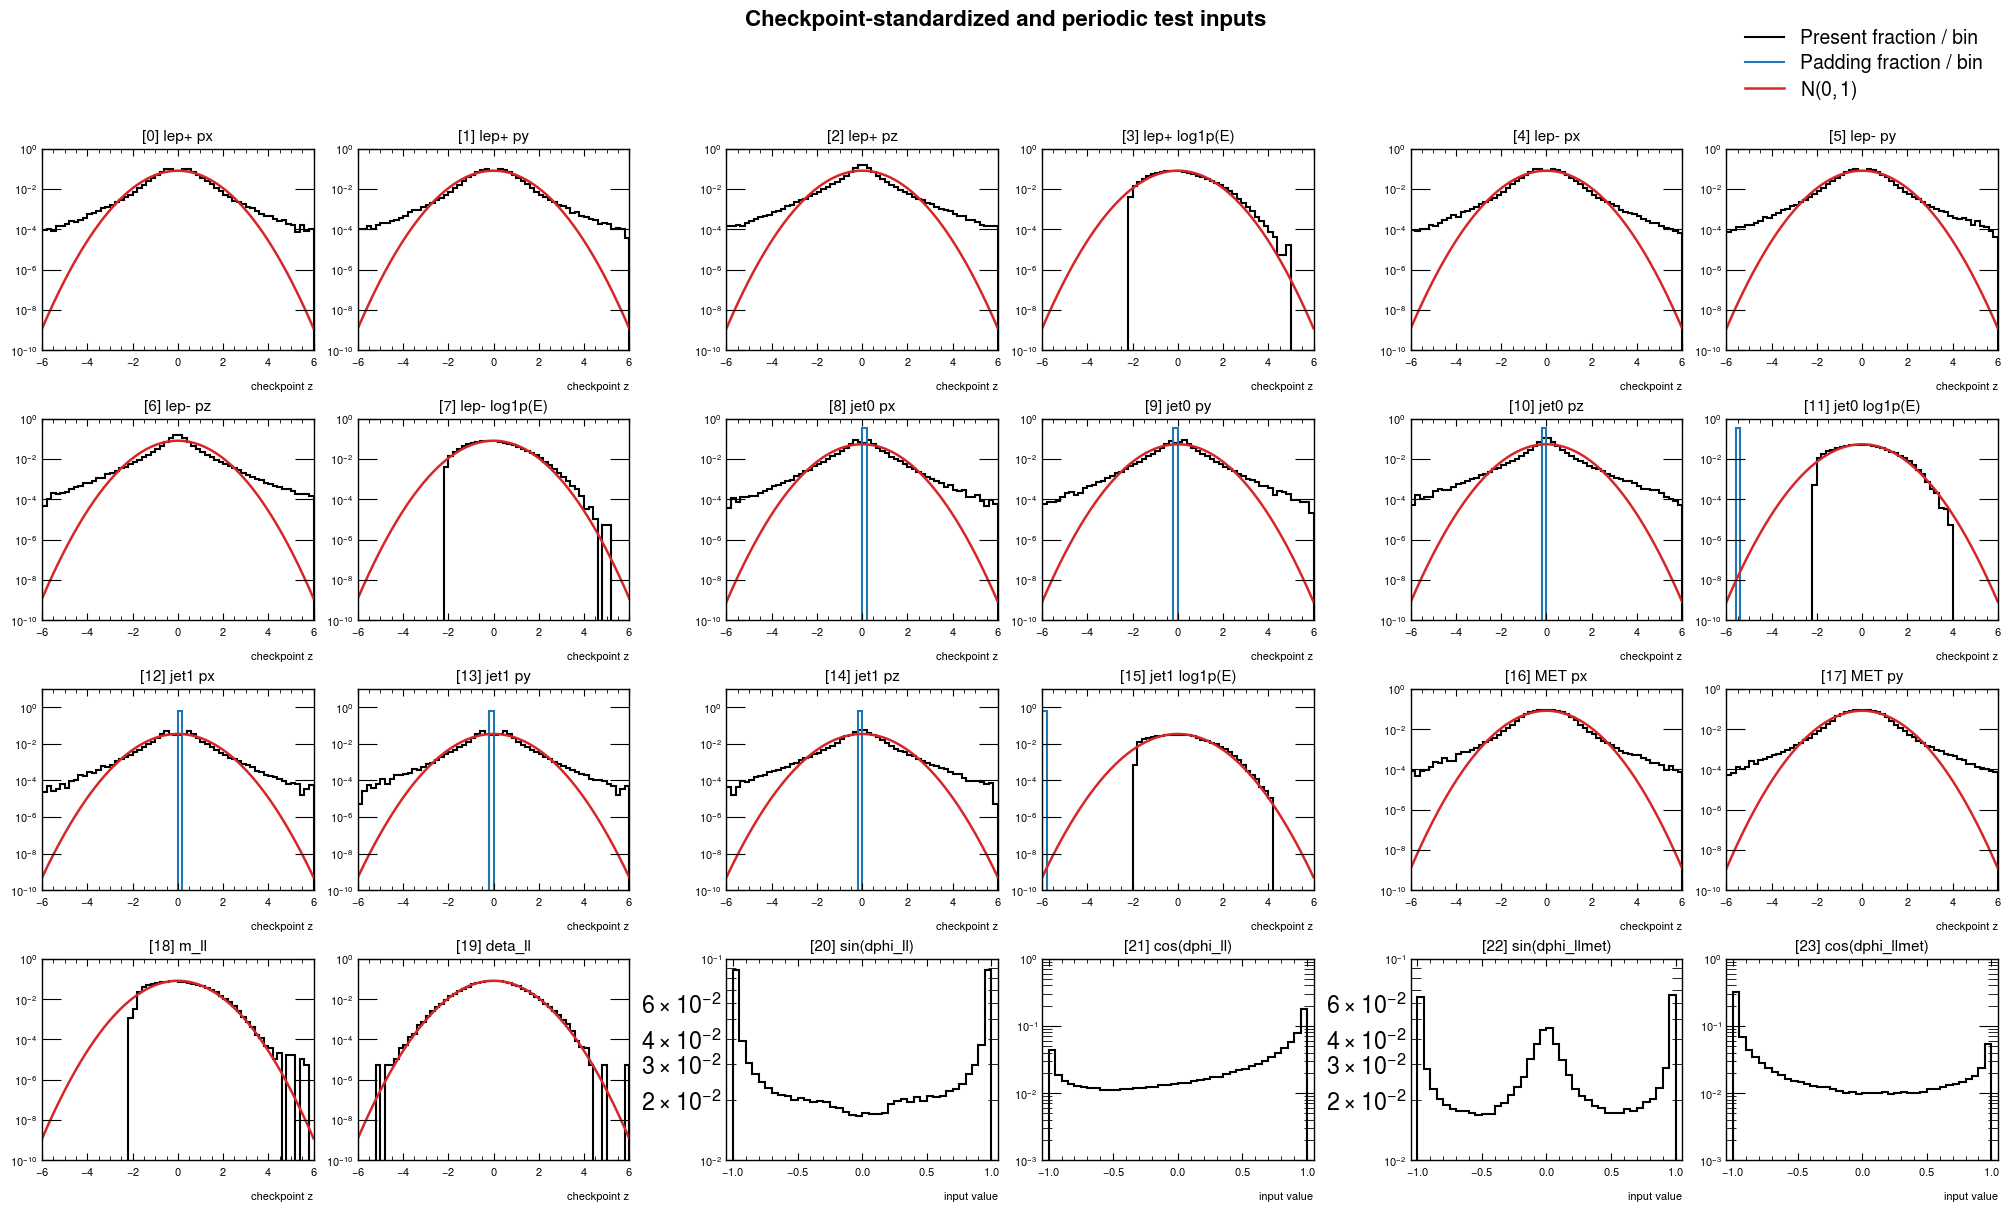

20 / 20 non-periodic features are well-conditioned (|z mean| < 0.05 and |z std - 1| < 0.1).


,n_events,n_present,n_padding,padding_fraction,z_mean,z_std,skew,kurtosis,|z|>2 [%],KS p-value,checkpoint scale
feature,,,,,,,,,,,
lep+ px,185968,185968,0,0.0000,0.0007,1.0009,-0.0477,6.9475,4.4588,0.0,30.055300
lep+ py,185968,185968,0,0.0000,-0.0001,0.9999,0.0245,8.0883,4.3954,0.0,30.025600
lep+ pz,185968,185968,0,0.0000,-0.0019,0.9967,0.0630,13.9750,5.4493,0.0,74.908798
lep+ log1p(E),185968,185968,0,0.0000,-0.0005,1.0000,0.3957,-0.1086,3.6334,0.0,0.703600
lep- px,185968,185968,0,0.0000,-0.0005,0.9978,0.0008,6.5101,4.4405,0.0,30.036301
lep- py,185968,185968,0,0.0000,-0.0037,1.0040,0.0423,6.6745,4.5766,0.0,30.021200
lep- pz,185968,185968,0,0.0000,0.0021,0.9957,0.1465,14.1492,5.4343,0.0,75.024200
lep- log1p(E),185968,185968,0,0.0000,0.0011,0.9966,0.3993,-0.0958,3.5571,0.0,0.704000
jet0 px,124150,124150,61818,0.3324,-0.0006,0.9984,0.0004,6.4282,5.3709,0.0,72.403900


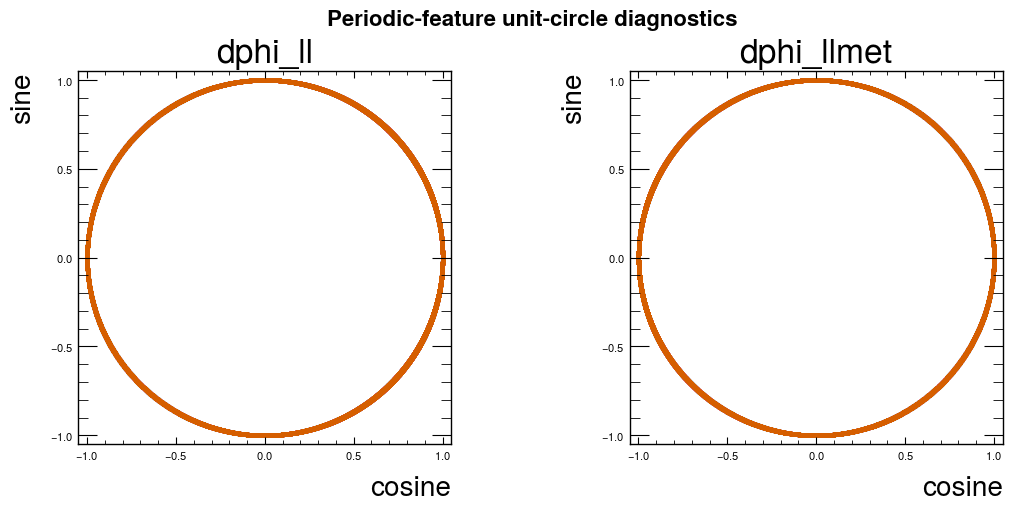

,all_finite,within_bounds,max_unit_circle_error
angle,,,
dphi_ll,True,True,1.192093e-07
dphi_llmet,True,True,1.192093e-07


In [5]:
# Diagnose the production neural-input representation without changing raw inputs.
from data.preprocessing import neural_input_features_numpy
from matplotlib.lines import Line2D
from scipy import stats as scipy_stats


feature_names = [
    "lep+ px", "lep+ py", "lep+ pz", "lep+ log1p(E)",
    "lep- px", "lep- py", "lep- pz", "lep- log1p(E)",
    "jet0 px", "jet0 py", "jet0 pz", "jet0 log1p(E)",
    "jet1 px", "jet1 py", "jet1 pz", "jet1 log1p(E)",
    "MET px", "MET py", "m_ll", "deta_ll",
    "sin(dphi_ll)", "cos(dphi_ll)",
    "sin(dphi_llmet)", "cos(dphi_llmet)",
]

test_candidate = neural_input_features_numpy(train_features)
checkpoint_mean = model.model.norm.mean.detach().cpu().numpy()
checkpoint_std = model.model.norm.std.detach().cpu().numpy()
if checkpoint_mean.shape != (24,) or checkpoint_std.shape != (24,):
    raise ValueError("Checkpoint normalization must contain 24 means and scales")
if not np.isfinite(checkpoint_mean).all() or not np.isfinite(checkpoint_std).all():
    raise ValueError("Checkpoint normalization statistics must be finite")
if np.any(checkpoint_std <= 0.0):
    raise ValueError("Checkpoint normalization scales must be positive")
features_z = (test_candidate - checkpoint_mean) / checkpoint_std

if features_z.shape[1] != 24 or not np.isfinite(features_z).all():
    raise ValueError("Candidate standardized features must be finite with 24 columns")

z_limits = (-6, 6)
z_edges = np.linspace(*z_limits, 61)
periodic_edges = np.linspace(-1.0, 1.0, 41)
all_events = np.ones(len(train_features), dtype=bool)
jet0_padding = (train_features[:, 8:12] == 0.0).all(axis=1)
jet1_padding = (train_features[:, 12:16] == 0.0).all(axis=1)
jet0_present = ~jet0_padding
jet1_present = ~jet1_padding
jet_present_masks = {**{i: jet0_present for i in range(8, 12)},
                     **{i: jet1_present for i in range(12, 16)}}
jet_padding_masks = {**{i: jet0_padding for i in range(8, 12)},
                     **{i: jet1_padding for i in range(12, 16)}}
fig, axes = plt.subplots(4, 6, figsize=(20, 12), constrained_layout=True)

summary_rows = []
for i, ax in enumerate(axes.flat):
    is_periodic = i >= 20
    plotted_features = test_candidate if is_periodic else features_z
    present_mask = jet_present_masks.get(i, all_events)
    padding_mask = jet_padding_masks.get(i)
    values = plotted_features[present_mask, i]
    plot_limits = z_limits
    if padding_mask is not None:
        padding_location = -checkpoint_mean[i] / checkpoint_std[i]
        padding_margin = (z_edges[1] - z_edges[0]) / 2.0
        plot_limits = (min(z_limits[0], padding_location - padding_margin),
                       max(z_limits[1], padding_location + padding_margin))
    plot_edges = periodic_edges if is_periodic else np.linspace(*plot_limits, len(z_edges))
    if len(values):
        event_weights = np.full(len(values), 1.0 / len(train_features))
        present_label = "Present fraction / bin" if padding_mask is not None else "Test fraction / bin"
        ax.hist(values, bins=plot_edges, weights=event_weights, histtype="step",
                linewidth=1.5, color="black", label=present_label)
    if padding_mask is not None:
        padding_values = features_z[padding_mask, i]
        if len(padding_values):
            padding_weights = np.full(len(padding_values), 1.0 / len(train_features))
            ax.hist(padding_values, bins=plot_edges, weights=padding_weights, histtype="step",
                    linewidth=1.5, color="tab:blue", label="Padding fraction / bin")
    if not is_periodic and len(values):
        distribution_summary = {
            "z_mean": values.mean(),
            "z_std": values.std(),
            "skew": scipy_stats.skew(values),
            "kurtosis": scipy_stats.kurtosis(values),
            "|z|>2 [%]": 100.0 * np.mean(np.abs(values) > 2),
            "KS p-value": scipy_stats.kstest(values, "norm").pvalue,
        }
    elif not is_periodic:
        distribution_summary = {
            metric: np.nan
            for metric in ("z_mean", "z_std", "skew", "kurtosis", "|z|>2 [%]", "KS p-value")
        }
    if is_periodic:
        ax.set_xlim(-1.05, 1.05)
        ax.set_xlabel("input value", fontsize=8)
    else:
        bin_width = plot_edges[1] - plot_edges[0]
        reference_scale = len(values) / len(train_features) if padding_mask is not None else 1.0
        reference_grid = np.linspace(*plot_limits, 400)
        ax.plot(reference_grid, scipy_stats.norm.pdf(reference_grid) * bin_width * reference_scale,
                color="tab:red", linewidth=1.8,
                label=r"$\mathcal{N}(0,1)$")
        ax.set_xlim(plot_limits)
        ax.set_xlabel("checkpoint z", fontsize=8)
    ax.set_yscale("log")
    ax.set_title(f"[{i}] {feature_names[i]}", fontsize=11)
    ax.tick_params(axis="both", labelsize=8)
    if not is_periodic:
        n_present = len(values)
        n_padding = np.count_nonzero(padding_mask) if padding_mask is not None else 0
        summary_rows.append({
            "feature": feature_names[i],
            "n_events": n_present,
            "n_present": n_present,
            "n_padding": n_padding,
            "padding_fraction": n_padding / len(train_features),
            **distribution_summary,
            "checkpoint scale": checkpoint_std[i],
        })

legend_handles = [
    Line2D([], [], color="black", linewidth=1.5, label="Present fraction / bin"),
    Line2D([], [], color="tab:blue", linewidth=1.5, label="Padding fraction / bin"),
    Line2D([], [], color="tab:red", linewidth=1.8, label=r"$\mathcal{N}(0,1)$"),
]
fig.legend(handles=legend_handles, loc="outside upper right", frameon=False)
fig.suptitle("Checkpoint-standardized and periodic test inputs", fontsize=16,
             fontweight="semibold")
plt.show()

summary_df = pd.DataFrame(summary_rows).set_index("feature")
well_conditioned = (
    (summary_df["z_mean"].abs() < 0.05)
    & ((summary_df["z_std"] - 1.0).abs() < 0.1)
)
print(f"{well_conditioned.sum()} / {len(summary_df)} non-periodic features are well-conditioned "
      f"(|z mean| < 0.05 and |z std - 1| < 0.1).")
display(summary_df.round(4))

angular_rows = []
fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
for ax, name, sin_index, cos_index in zip(
    axes, ("dphi_ll", "dphi_llmet"), (20, 22), (21, 23)
):
    sin_values = test_candidate[:, sin_index]
    cos_values = test_candidate[:, cos_index]
    radius_squared = sin_values**2 + cos_values**2
    angular_rows.append({
        "angle": name,
        "all_finite": np.isfinite(sin_values).all() and np.isfinite(cos_values).all(),
        "within_bounds": (np.abs(sin_values) <= 1.0).all() and (np.abs(cos_values) <= 1.0).all(),
        "max_unit_circle_error": np.max(np.abs(radius_squared - 1.0)),
    })
    ax.scatter(cos_values, sin_values, s=5, alpha=0.25, rasterized=True)
    ax.set(xlim=(-1.05, 1.05), ylim=(-1.05, 1.05), aspect="equal",
           xlabel="cosine", ylabel="sine", title=name)
    ax.tick_params(axis="both", labelsize=8)
fig.suptitle("Periodic-feature unit-circle diagnostics", fontsize=16, fontweight="semibold")
plt.show()

angular_summary_df = pd.DataFrame(angular_rows).set_index("angle")
display(angular_summary_df)

In [6]:
pred_w0_px = predictions[..., 0]
pred_w0_py = predictions[..., 1]
pred_w0_pz = predictions[..., 2]
pred_w0_energy = predictions[..., 3]
pred_w1_px = predictions[..., 4]
pred_w1_py = predictions[..., 5]
pred_w1_pz = predictions[..., 6]
pred_w1_energy = predictions[..., 7]
pred_w0_mass_2 = pred_w0_energy**2 - (pred_w0_px**2 + pred_w0_py**2 + pred_w0_pz**2)
pred_w1_mass_2 = pred_w1_energy**2 - (pred_w1_px**2 + pred_w1_py**2 + pred_w1_pz**2)

true_w0_px = true_labels[..., 0]
true_w0_py = true_labels[..., 1]
true_w0_pz = true_labels[..., 2]
true_w0_energy = true_labels[..., 3]
true_w1_px = true_labels[..., 4]
true_w1_py = true_labels[..., 5]
true_w1_pz = true_labels[..., 6]
true_w1_energy = true_labels[..., 7]
true_w0_mass_2 = true_labels[..., 8] ** 2
true_w1_mass_2 = true_labels[..., 9] ** 2

In [7]:
component_names = ["W+ px", "W+ py", "W+ pz", "W+ E", "W- px", "W- py", "W- pz", "W- E"]
calibration = component_calibration(predictions[:, :8], true_labels[:, :8])
diagnostic_rows = []
for index, name in enumerate(component_names):
    pred = predictions[:, index]
    truth = true_labels[:, index]
    valid = np.isfinite(pred) & np.isfinite(truth)
    diagnostic_rows.append({
        "component": name,
        "pred_mean": pred[valid].mean() if valid.any() else np.nan,
        "truth_mean": truth[valid].mean() if valid.any() else np.nan,
        **{metric: values[index] for metric, values in calibration.items()},
    })

fourvec_diagnostics = pd.DataFrame(diagnostic_rows).set_index("component")
display(fourvec_diagnostics.round(4))

,pred_mean,truth_mean,bias,width_ratio,correlation,slope,intercept,rmse
component,,,,,,,,
W+ px,-3.092200,0.001500,-3.0937,0.9181,0.8941,0.8209,-3.0935,18.2252
W+ py,3.524500,-0.021900,3.5464,0.9208,0.8948,0.8239,3.5426,18.1882
W+ pz,-3.597000,0.142600,-3.7396,0.7390,0.8158,0.6029,-3.6830,87.5833
W+ E,113.146103,132.835602,-19.6895,0.7122,0.7426,0.5289,42.8877,75.0048
W- px,2.788900,0.047400,2.7415,0.9221,0.8929,0.8233,2.7498,18.1765
W- py,-3.574200,-0.171800,-3.4024,0.9230,0.8955,0.8266,-3.4322,18.1235
W- pz,3.835400,0.128100,3.7074,0.7331,0.8163,0.5985,3.7588,88.0308
W- E,112.980698,133.006699,-20.0260,0.7038,0.7410,0.5215,43.6167,75.7904


In [8]:
pred_nu0_px = pred_w0_px - true_lep0_px
pred_nu0_py = pred_w0_py - true_lep0_py
pred_nu0_pz = pred_w0_pz - true_lep0_pz

pred_nu1_px = pred_w1_px - true_lep1_px
pred_nu1_py = pred_w1_py - true_lep1_py
pred_nu1_pz = pred_w1_pz - true_lep1_pz

pred_dinu_px = pred_nu0_px + pred_nu1_px
pred_dinu_py = pred_nu0_py + pred_nu1_py
pred_dinu_pt = np.sqrt(pred_dinu_px**2 + pred_dinu_py**2)


true_nu0_px = true_w0_px - true_lep0_px
true_nu0_py = true_w0_py - true_lep0_py
true_nu0_pz = true_w0_pz - true_lep0_pz

true_nu1_px = true_w1_px - true_lep1_px
true_nu1_py = true_w1_py - true_lep1_py
true_nu1_pz = true_w1_pz - true_lep1_pz

true_dinu_px = true_nu0_px + true_nu1_px
true_dinu_py = true_nu0_py + true_nu1_py
true_dinu_pt = np.sqrt(true_dinu_px**2 + true_dinu_py**2)

pred_dmet_px = pred_dmet[:, 0]
pred_dmet_py = pred_dmet[:, 1]
pred_dmet_pt = np.sqrt(pred_dmet_px**2 + pred_dmet_py**2)

true_dmet_px = true_met_px - true_dinu_px
true_dmet_py = true_met_py - true_dinu_py
true_dmet_pt = np.sqrt(true_dmet_px**2 + true_dmet_py**2)

pred_neutrino_met_px = true_met_px - pred_dmet_px
pred_neutrino_met_py = true_met_py - pred_dmet_py
pred_neutrino_met_pt = np.sqrt(pred_neutrino_met_px**2 + pred_neutrino_met_py**2)

In [9]:
# bins = np.linspace(-100, 100, 51)
# plot_1d_hist(pred_dmet_px, true_dmet_px, r"$\Delta E_{T,x}^{miss}$", bins_edges=bins, unit="GeV")
# plot_2d_hist(pred_dmet_px, true_dmet_px, r"$\Delta E_{T,x}^{miss}$", bins_edges=bins, log=True, unit="GeV", vmax=2e3)
# plot_1d_hist(pred_dmet_py, true_dmet_py, r"$\Delta E_{T,y}^{miss}$", bins_edges=bins, unit="GeV")
# plot_2d_hist(pred_dmet_py, true_dmet_py, r"$\Delta E_{T,y}^{miss}$", bins_edges=bins, log=True, unit="GeV", vmax=2e3)

# pt_bins = np.linspace(0, 150, 51)
# plot_1d_hist(pred_dmet_pt, true_dmet_pt, r"$|\Delta E_T^{miss}|$", bins_edges=pt_bins, unit="GeV")
# plot_2d_hist(pred_dmet_pt, true_dmet_pt, r"$|\Delta E_T^{miss}|$", bins_edges=pt_bins, log=True, unit="GeV", vmax=2e3)

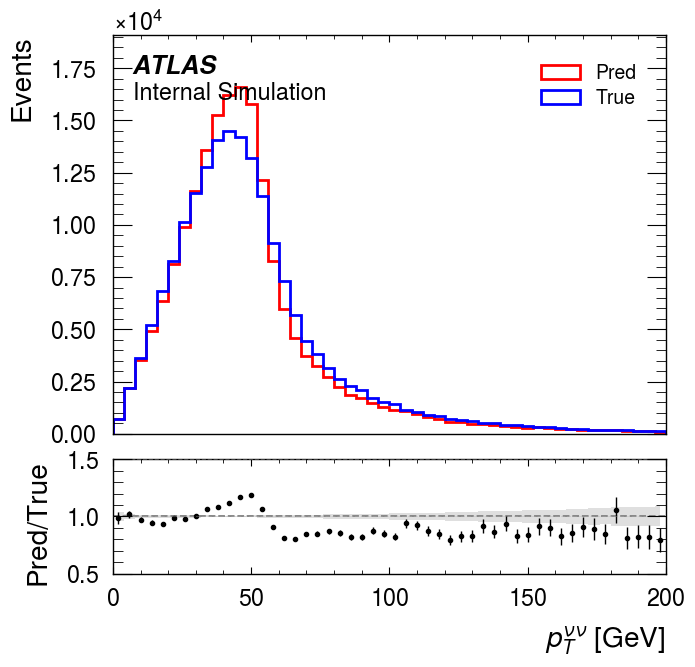

Rel err < 20%: 49.68 %


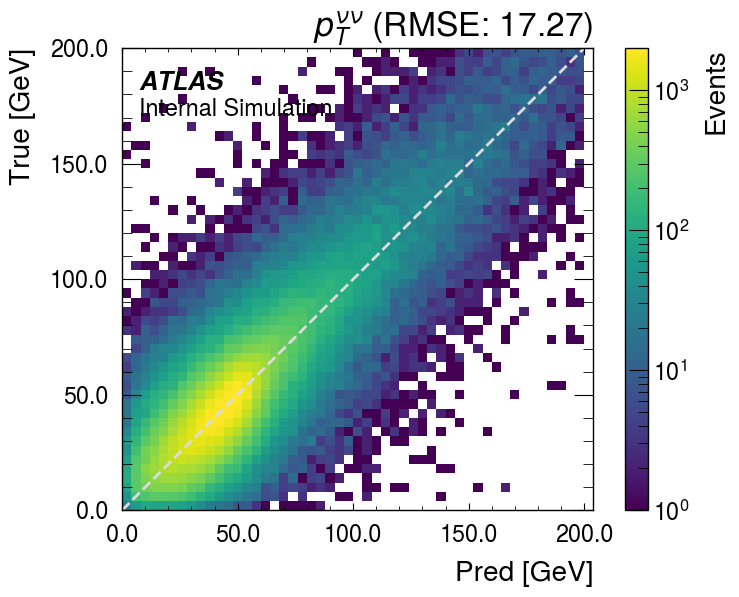

In [10]:
plot_1d_hist(pred_dinu_pt, true_dinu_pt, r"$p_T^{\nu\nu}$", bins_edges=np.linspace(0, 200, 51), unit="GeV")
plot_2d_hist(pred_dinu_pt, true_dinu_pt, r"$p_T^{\nu\nu}$", bins_edges=np.linspace(0, 200, 51), log=True, unit="GeV", vmax=2e3)

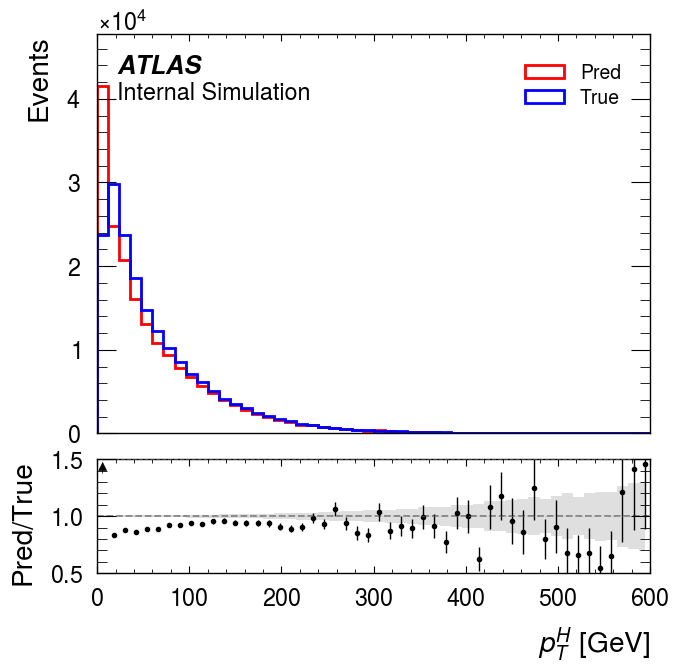

Rel err < 20%: 43.58 %


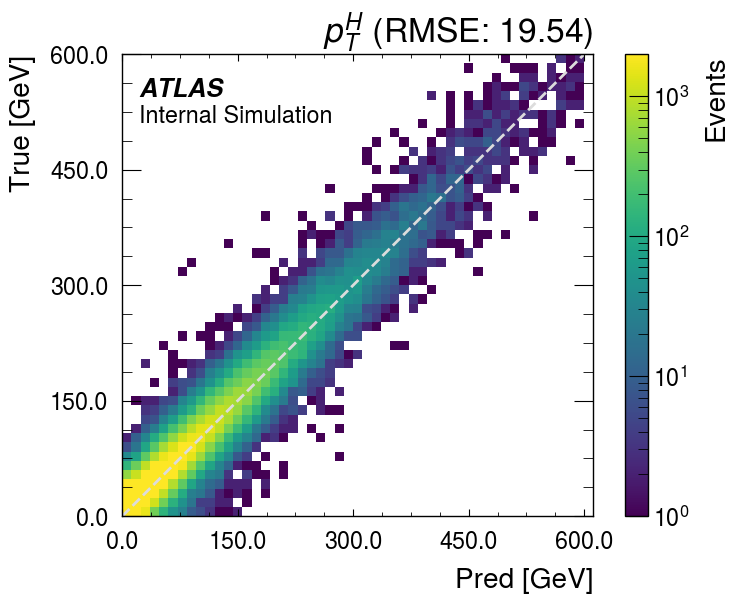

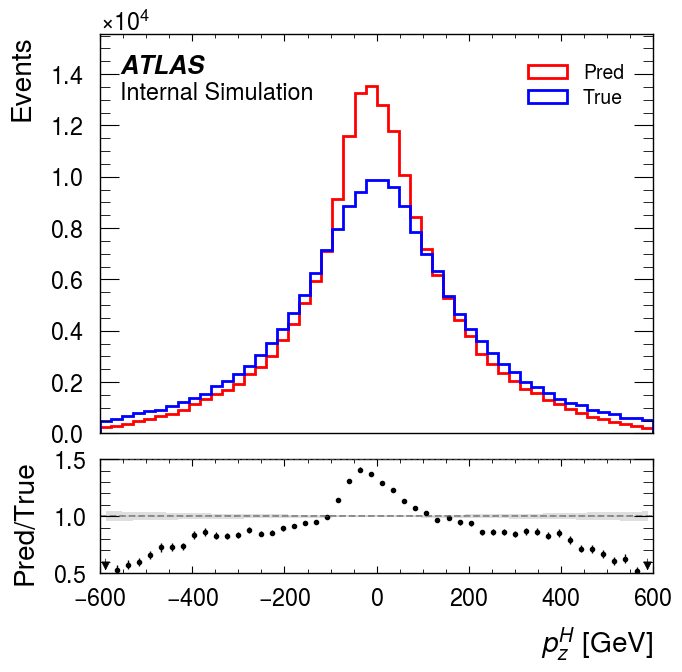

Rel err < 20%: 25.10 %


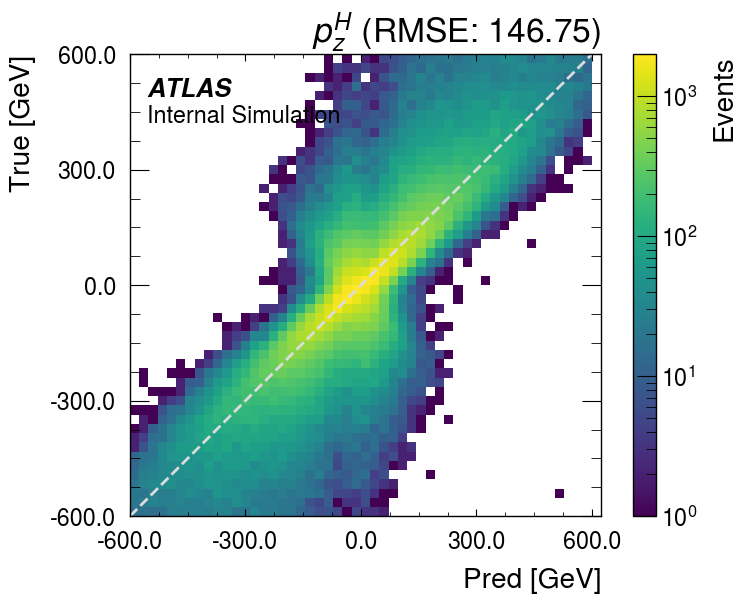

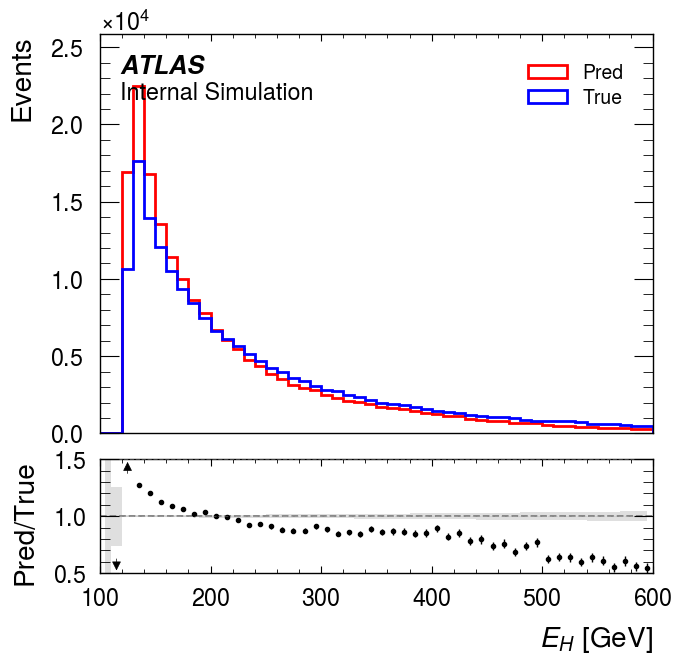

Rel err < 20%: 66.62 %


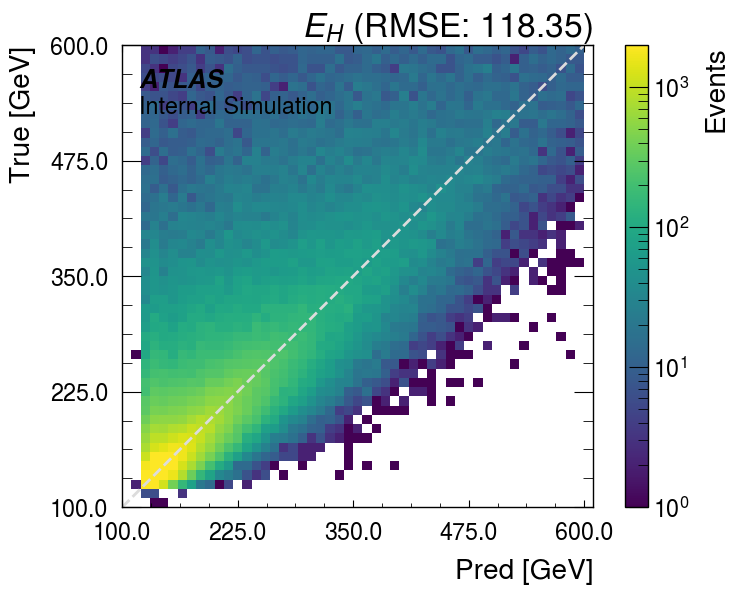

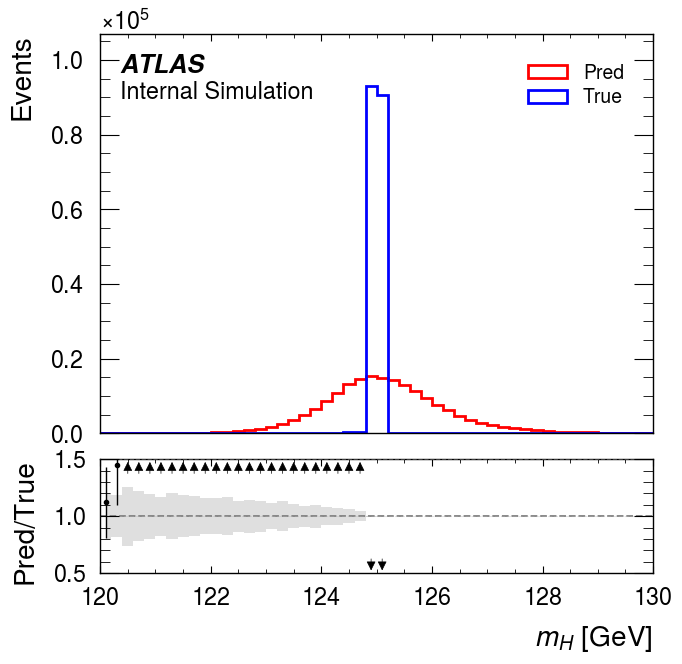

Mean predicted Higgs mass: 125.18 GeV, Std: 2.55 GeV
Rel err < 20%: 99.97 %


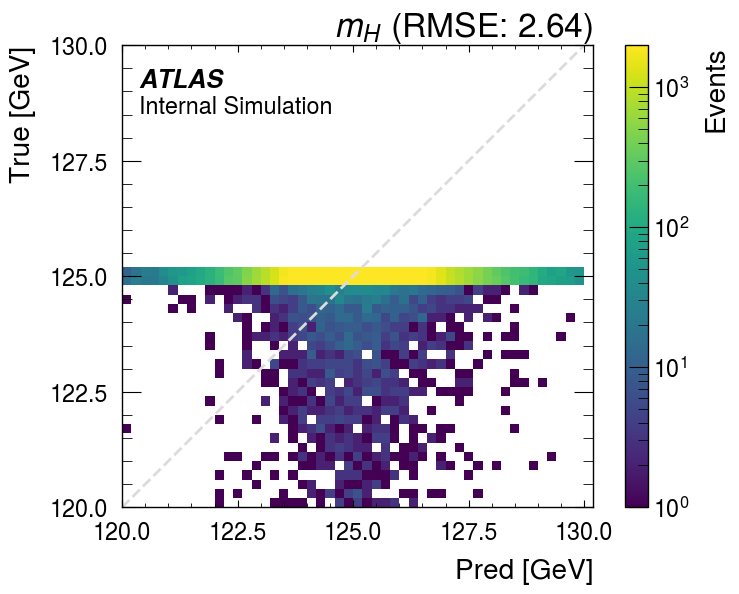

In [11]:
def safe_mass(mass2):
    return np.sqrt(np.abs(mass2))

pred_higgs_px = pred_w0_px + pred_w1_px
pred_higgs_py = pred_w0_py + pred_w1_py
pred_higgs_pz = pred_w0_pz + pred_w1_pz
pred_higgs_pt = np.sqrt(pred_higgs_px**2 + pred_higgs_py**2)
pred_higgs_energy = pred_w0_energy + pred_w1_energy
pred_higgs_mass_2 = pred_higgs_energy**2 - (pred_higgs_px**2 + pred_higgs_py**2 + pred_higgs_pz**2)
pred_higgs_mass = safe_mass(pred_higgs_mass_2)

true_higgs_px = true_w0_px + true_w1_px
true_higgs_py = true_w0_py + true_w1_py
true_higgs_pz = true_w0_pz + true_w1_pz
true_higgs_pt = np.sqrt(true_higgs_px**2 + true_higgs_py**2)
true_higgs_energy = true_w0_energy + true_w1_energy
true_higgs_mass_2 = true_higgs_energy**2 - (true_higgs_px**2 + true_higgs_py**2 + true_higgs_pz**2)
true_higgs_mass = safe_mass(true_higgs_mass_2)

# plot_1d_hist(pred_higgs_px, true_higgs_px, "$p_x^{H}$", bins_edges=np.linspace(-200, 200, 51), unit="GeV")
# plot_2d_hist(pred_higgs_px, true_higgs_px, "$p_x^{H}$", bins_edges=np.linspace(-200, 200, 51), log=True, unit="GeV", vmax=2e3)
# plot_1d_hist(pred_higgs_py, true_higgs_py, "$p_y^{H}$", bins_edges=np.linspace(-200, 200, 51), unit="GeV")
# plot_2d_hist(pred_higgs_py, true_higgs_py, "$p_y^{H}$", bins_edges=np.linspace(-200, 200, 51), log=True, unit="GeV", vmax=2e3)
plot_1d_hist(pred_higgs_pt, true_higgs_pt, "$p_T^{H}$", bins_edges=np.linspace(0, 600, 51), unit="GeV")
plot_2d_hist(pred_higgs_pt, true_higgs_pt, "$p_T^{H}$", bins_edges=np.linspace(0, 600, 51), log=True, unit="GeV", vmax=2e3)
plot_1d_hist(pred_higgs_pz, true_higgs_pz, "$p_z^{H}$", bins_edges=np.linspace(-600, 600, 51), unit="GeV")
plot_2d_hist(pred_higgs_pz, true_higgs_pz, "$p_z^{H}$", bins_edges=np.linspace(-600, 600, 51), log=True, unit="GeV", vmax=2e3)
plot_1d_hist(pred_higgs_energy, true_higgs_energy, "$E_H$", bins_edges=np.linspace(100, 600, 51), unit="GeV")
plot_2d_hist(pred_higgs_energy, true_higgs_energy, "$E_H$", bins_edges=np.linspace(100, 600, 51), log=True, unit="GeV", vmax=2e3)
plot_1d_hist(pred_higgs_mass, true_higgs_mass, "$m_H$", bins_edges=np.linspace(120, 130, 51), unit="GeV")
print(f"Mean predicted Higgs mass: {pred_higgs_mass.mean():.2f} GeV, Std: {pred_higgs_mass.std():.2f} GeV")
plot_2d_hist(pred_higgs_mass, true_higgs_mass, "$m_H$", bins_edges=np.linspace(120, 130, 51), log=True, unit="GeV", vmax=2e3)


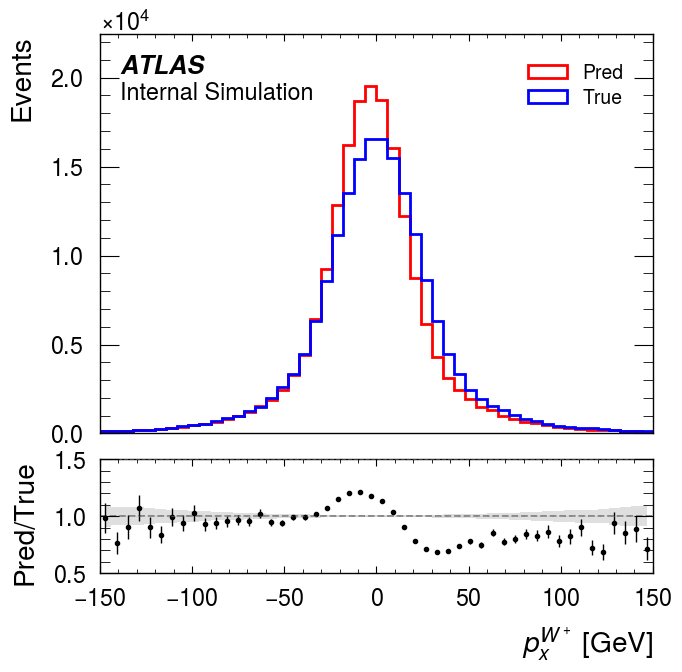

Rel err < 20%: 21.26 %


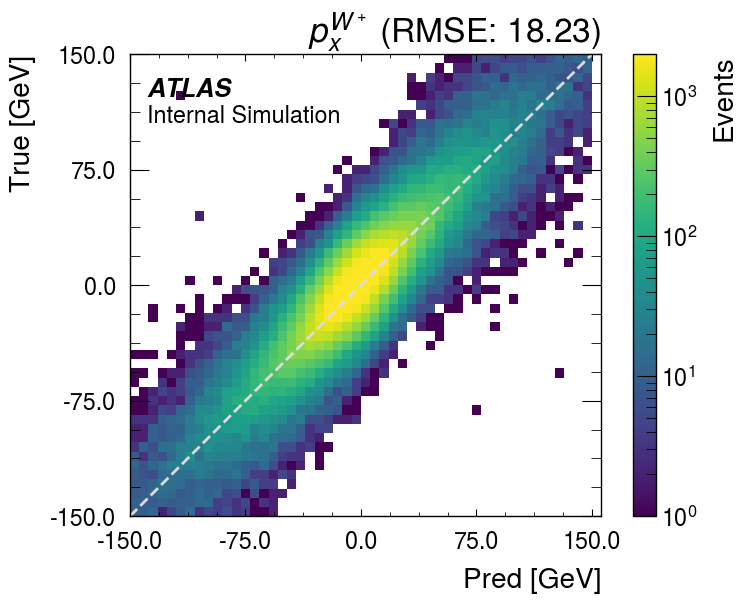

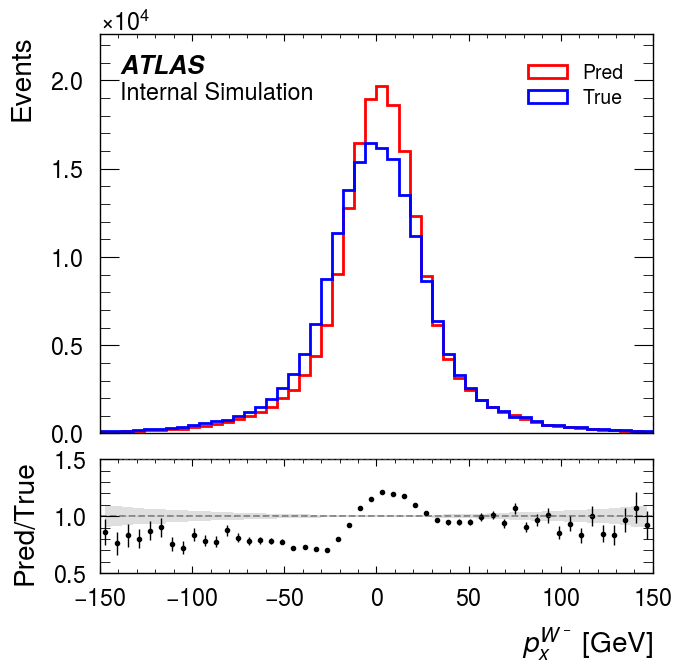

Rel err < 20%: 21.30 %


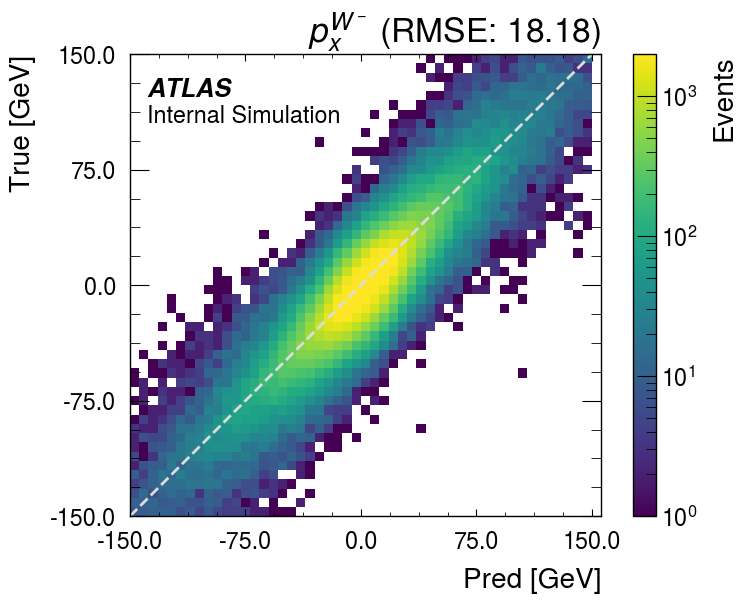

In [12]:
bins = np.linspace(-150, 150, 51)
plot_1d_hist(pred_w0_px, true_w0_px, bins_edges=bins, name=r"$p_x^{W^+}$")
plot_2d_hist(pred_w0_px, true_w0_px, name=r"$p_x^{W^+}$", bins_edges=bins, log=True, vmax=2e3)
plot_1d_hist(pred_w1_px, true_w1_px, bins_edges=bins, name=r"$p_x^{W^-}$")
plot_2d_hist(pred_w1_px, true_w1_px, name=r"$p_x^{W^-}$", bins_edges=bins, log=True, vmax=2e3)

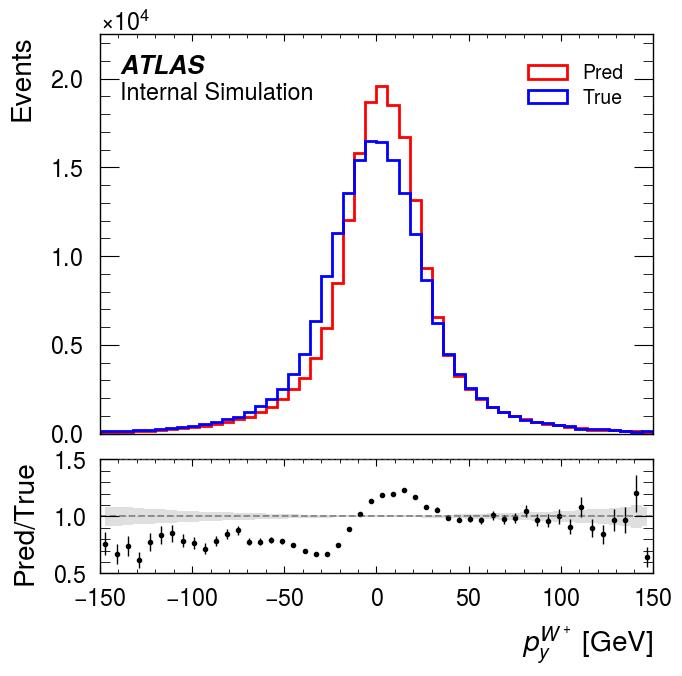

Rel err < 20%: 21.41 %


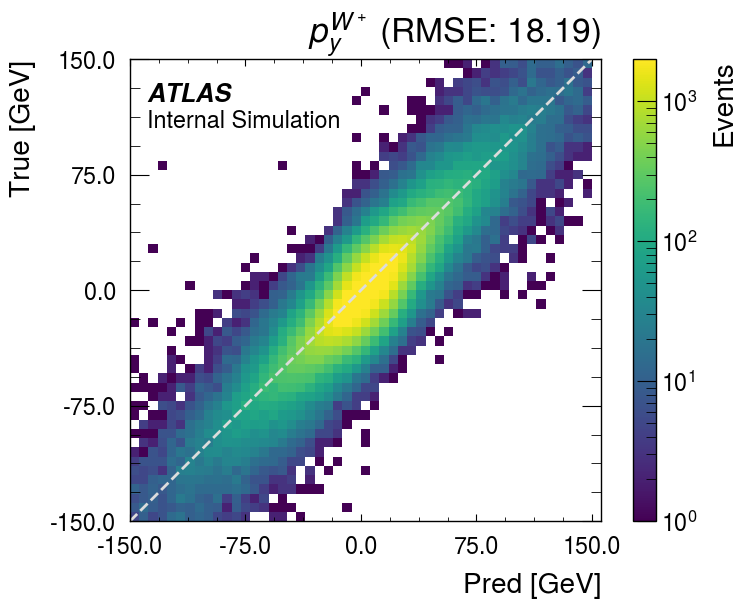

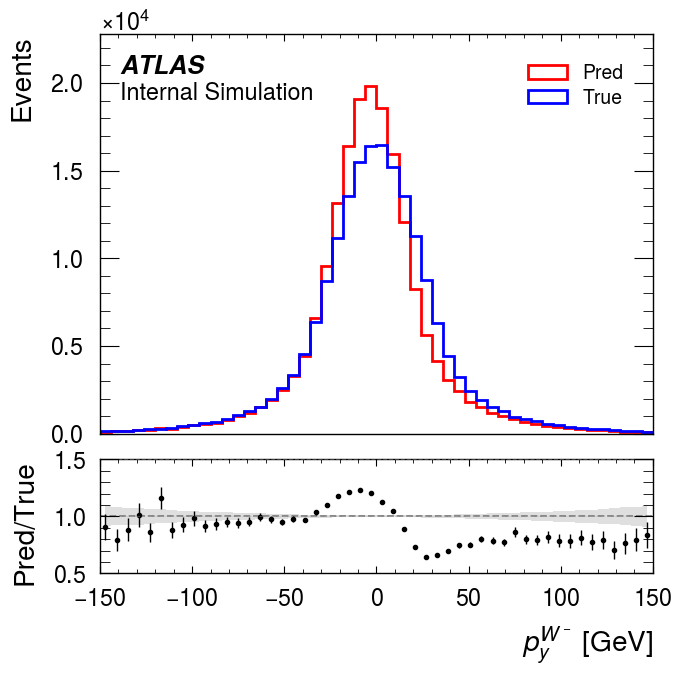

Rel err < 20%: 21.63 %


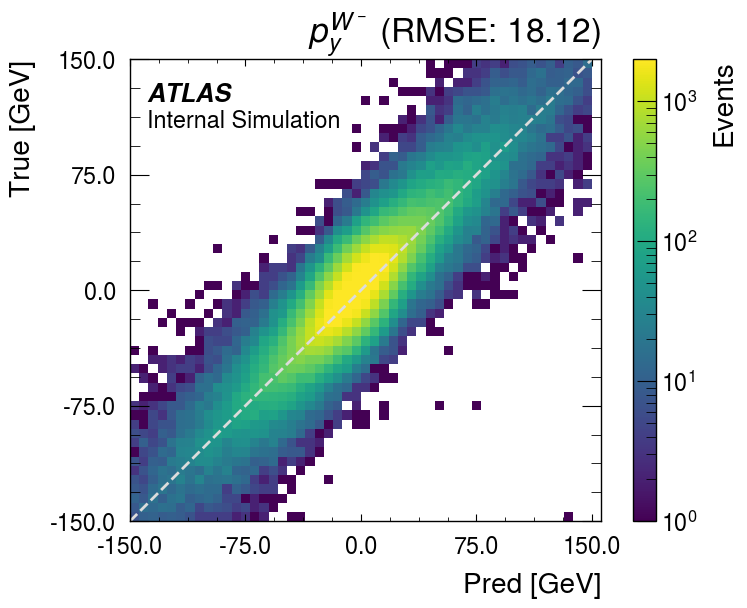

In [13]:
bins = np.linspace(-150, 150, 51)
plot_1d_hist(pred_w0_py, true_w0_py, bins_edges=bins, name=r"$p_y^{W^+}$")
plot_2d_hist(pred_w0_py, true_w0_py, name=r"$p_y^{W^+}$", bins_edges=bins, log=True, vmax=2e3)
plot_1d_hist(pred_w1_py, true_w1_py, bins_edges=bins, name=r"$p_y^{W^-}$")
plot_2d_hist(pred_w1_py, true_w1_py, name=r"$p_y^{W^-}$", bins_edges=bins, log=True, vmax=2e3)

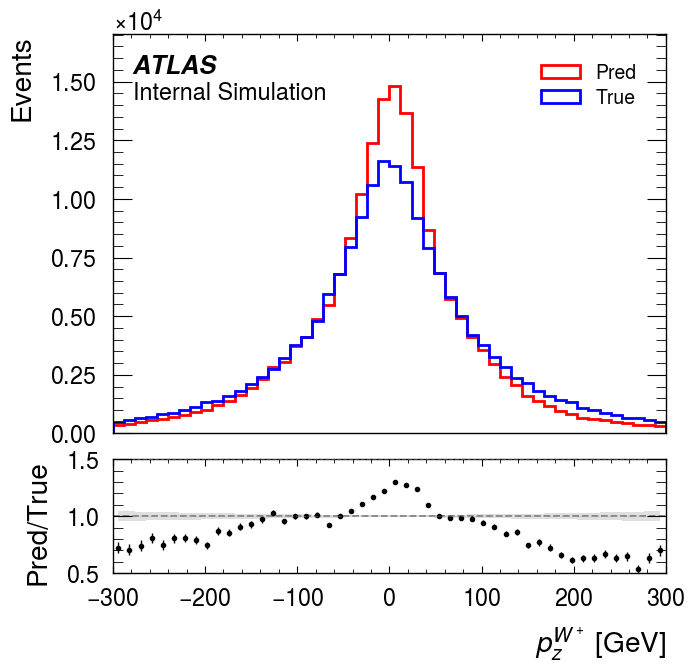

Rel err < 20%: 20.39 %


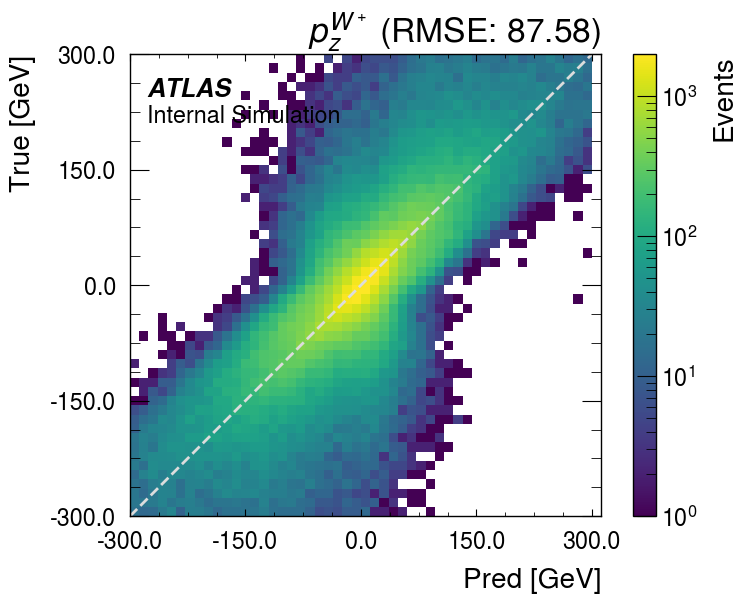

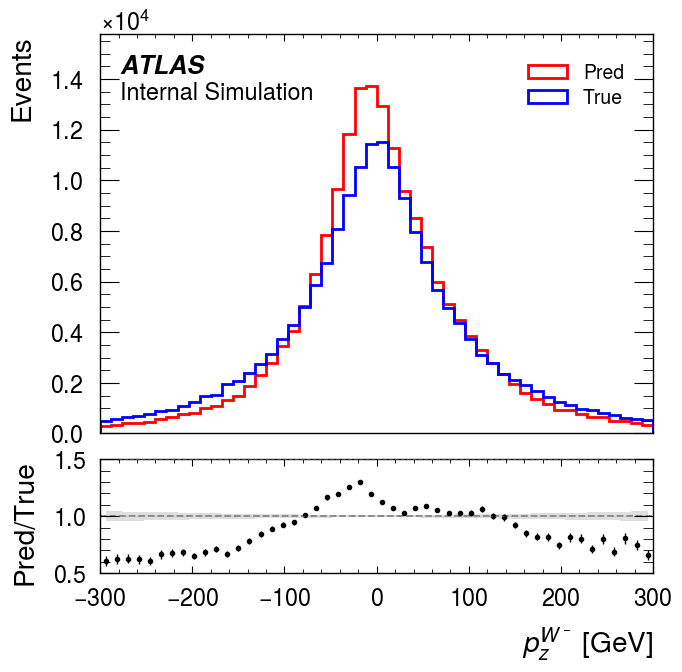

Rel err < 20%: 20.69 %


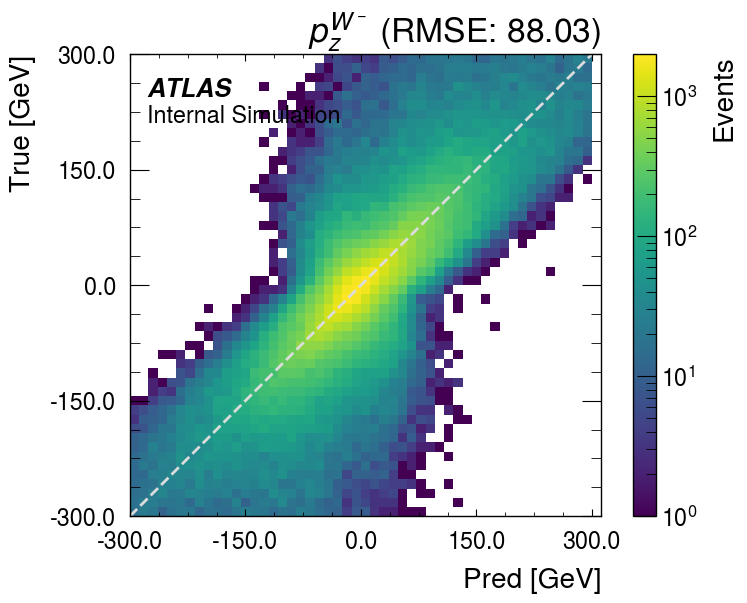

In [14]:
bins = np.linspace(-300, 300, 51)
plot_1d_hist(pred_w0_pz, true_w0_pz, bins_edges=bins, name=r"$p_z^{W^+}$")
plot_2d_hist(pred_w0_pz, true_w0_pz, name=r"$p_z^{W^+}$", bins_edges=bins, log=True, vmax=2e3)
plot_1d_hist(pred_w1_pz, true_w1_pz, bins_edges=bins, name=r"$p_z^{W^-}$")
plot_2d_hist(pred_w1_pz, true_w1_pz, name=r"$p_z^{W^-}$", bins_edges=bins, log=True, vmax=2e3)

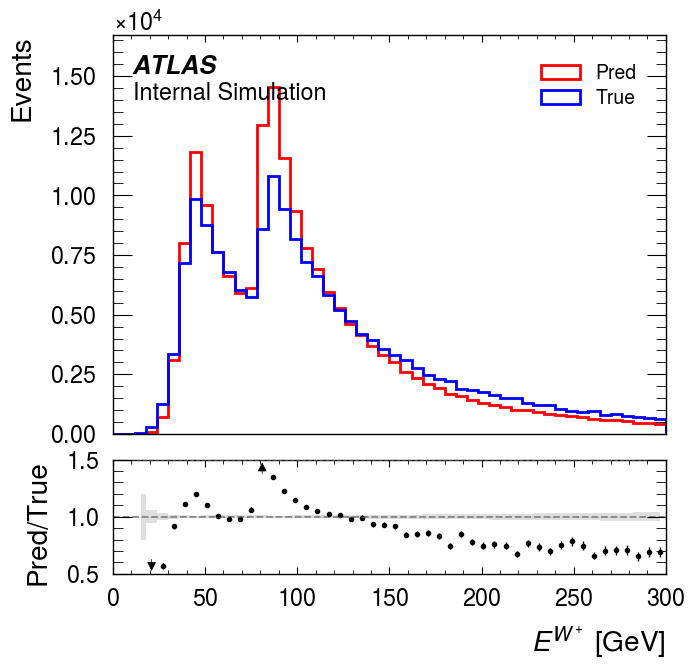

Rel err < 20%: 49.58 %


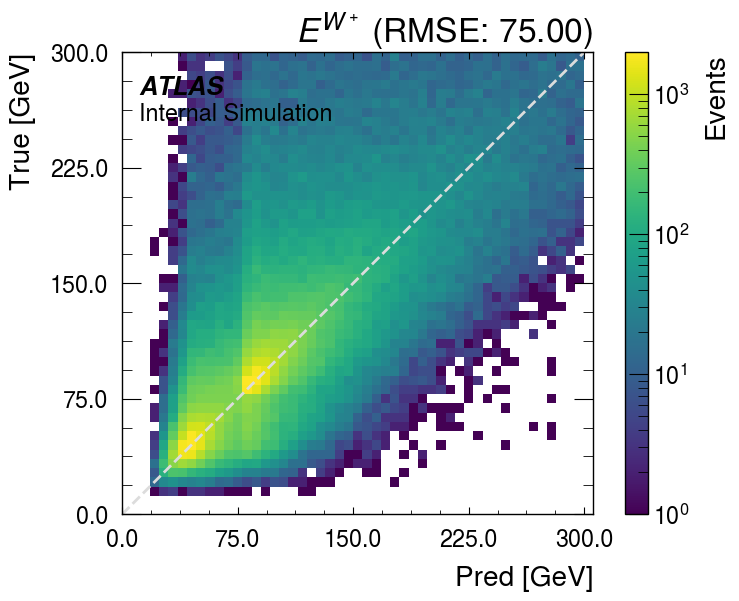

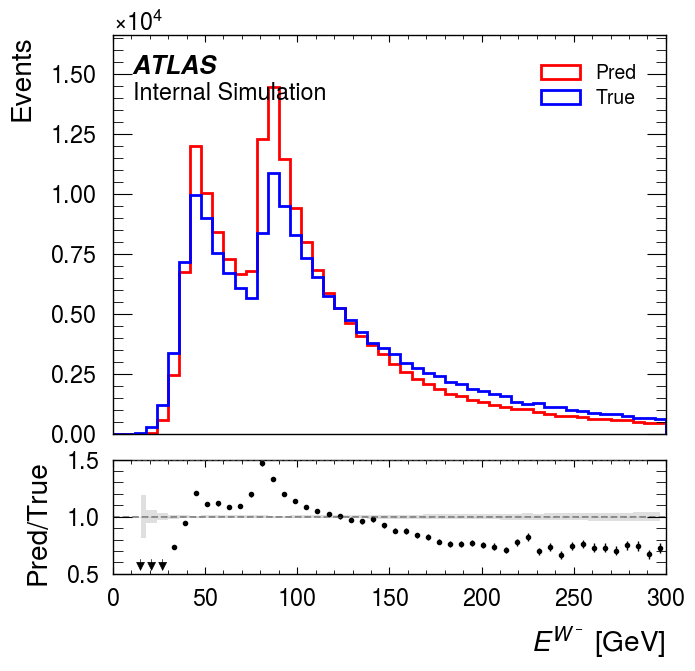

Rel err < 20%: 49.64 %


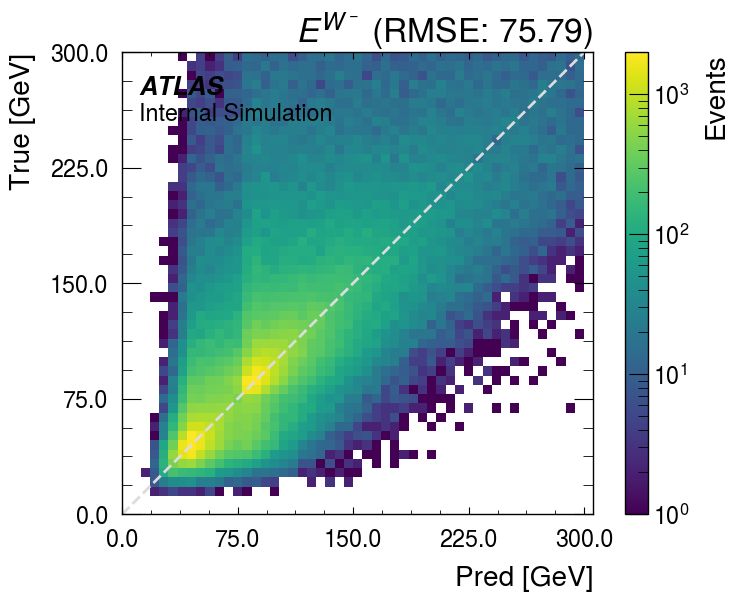

In [15]:
bins = np.linspace(0, 300, 51)
plot_1d_hist(pred_w0_energy, true_w0_energy, bins_edges=bins, name=r"$E^{W^+}$")
plot_2d_hist(pred_w0_energy, true_w0_energy, name=r"$E^{W^+}$", bins_edges=bins, log=True, color="black", vmax=2e3)
plot_1d_hist(pred_w1_energy, true_w1_energy, bins_edges=bins, name=r"$E^{W^-}$")
plot_2d_hist(pred_w1_energy, true_w1_energy, name=r"$E^{W^-}$", bins_edges=bins, log=True, color="black", vmax=2e3)

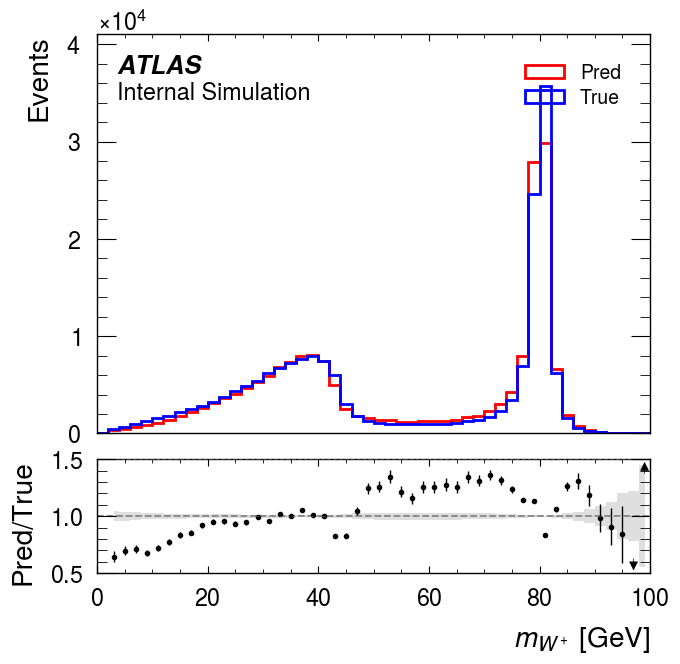

Rel err < 20%: 57.44 %


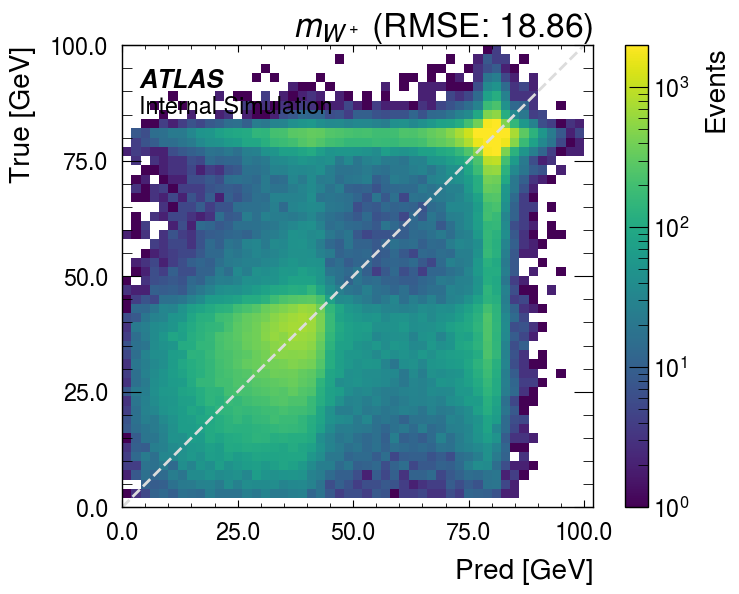

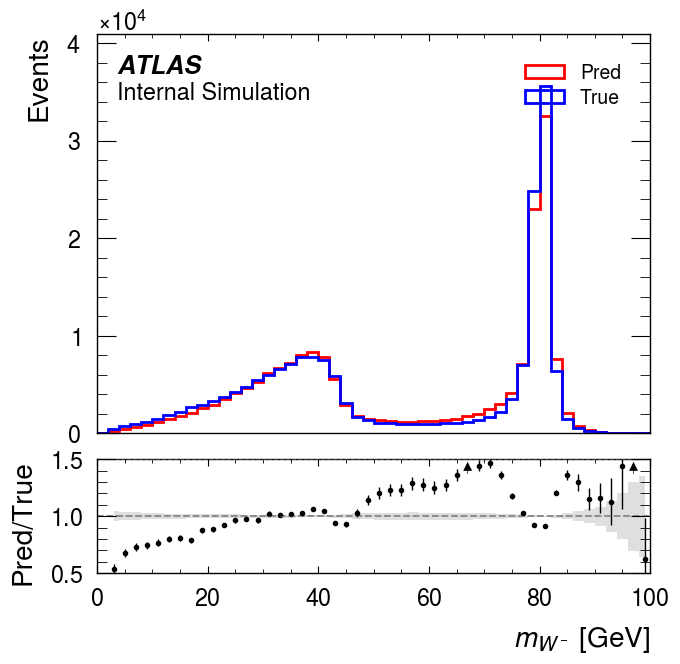

Rel err < 20%: 57.14 %


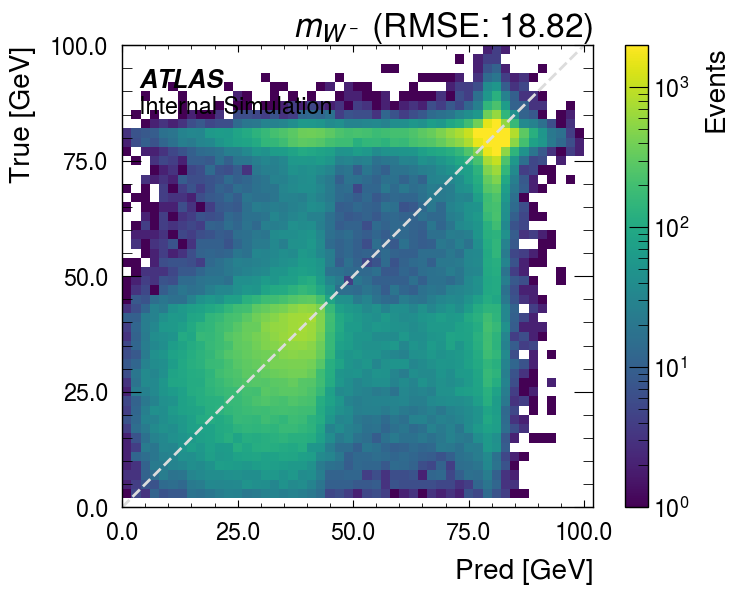

In [16]:
bins = np.linspace(0, 100, 51)
pred_w0_mass = safe_mass(pred_w0_mass_2)
pred_w1_mass = safe_mass(pred_w1_mass_2)
true_w0_mass = safe_mass(true_w0_mass_2)
true_w1_mass = safe_mass(true_w1_mass_2)

plot_1d_hist(pred_w0_mass, true_w0_mass, bins_edges=bins, name=r"$m_{W^+}$", unit="GeV")
plot_2d_hist(pred_w0_mass, true_w0_mass, name=r"$m_{W^+}$", bins_edges=bins, log=True, unit="GeV", vmax=2e3)
plot_1d_hist(pred_w1_mass, true_w1_mass, bins_edges=bins, name=r"$m_{W^-}$", unit="GeV")
plot_2d_hist(pred_w1_mass, true_w1_mass, name=r"$m_{W^-}$", bins_edges=bins, log=True, unit="GeV", vmax=2e3)


In [17]:
# bins = np.linspace(0, 100, 51)

# # W0: infer the neutrino from the predicted W and test the swapped lepton.
# diff_w0 = pred_w0_mass - true_w0_mass
# pred_nu0_px = pred_w0_px - true_lep0_px
# pred_nu0_py = pred_w0_py - true_lep0_py
# pred_nu0_pz = pred_w0_pz - true_lep0_pz
# pred_nu0_energy = pred_w0_energy - true_lep0_energy
# pred_nu0_mass_2 = (
#     pred_nu0_energy**2
#     - (pred_nu0_px**2 + pred_nu0_py**2 + pred_nu0_pz**2)
# )
# pred_nu0_mass = safe_mass(pred_nu0_mass_2)

# pred_w0_px_swap = pred_nu0_px + true_lep1_px
# pred_w0_py_swap = pred_nu0_py + true_lep1_py
# pred_w0_pz_swap = pred_nu0_pz + true_lep1_pz
# pred_w0_energy_swap = pred_nu0_energy + true_lep1_energy
# pred_w0_mass_swap = safe_mass(
#     pred_w0_energy_swap**2
#     - (pred_w0_px_swap**2 + pred_w0_py_swap**2 + pred_w0_pz_swap**2)
# )
# diff_w0_swap = pred_w0_mass_swap - true_w0_mass
# corr_mask_w0 = np.abs(diff_w0_swap) < np.abs(diff_w0)
# corr_pred_w0_px = np.where(corr_mask_w0, pred_w0_px_swap, pred_w0_px)
# corr_pred_w0_py = np.where(corr_mask_w0, pred_w0_py_swap, pred_w0_py)
# corr_pred_w0_pz = np.where(corr_mask_w0, pred_w0_pz_swap, pred_w0_pz)
# corr_pred_w0_energy = np.where(corr_mask_w0, pred_w0_energy_swap, pred_w0_energy)
# corr_pred_w0_p4 = np.stack([corr_pred_w0_px, corr_pred_w0_py, corr_pred_w0_pz, corr_pred_w0_energy], axis=1)
# corr_pred_w0_mass = np.where(corr_mask_w0, pred_w0_mass_swap, pred_w0_mass)

# # W1: mirror the same correction using the opposite lepton assignment.
# diff_w1 = pred_w1_mass - true_w1_mass
# pred_nu1_px = pred_w1_px - true_lep1_px
# pred_nu1_py = pred_w1_py - true_lep1_py
# pred_nu1_pz = pred_w1_pz - true_lep1_pz
# pred_nu1_energy = pred_w1_energy - true_lep1_energy
# pred_nu1_mass_2 = (
#     pred_nu1_energy**2
#     - (pred_nu1_px**2 + pred_nu1_py**2 + pred_nu1_pz**2)
# )
# pred_nu1_mass = safe_mass(pred_nu1_mass_2)

# pred_w1_px_swap = pred_nu1_px + true_lep0_px
# pred_w1_py_swap = pred_nu1_py + true_lep0_py
# pred_w1_pz_swap = pred_nu1_pz + true_lep0_pz
# pred_w1_energy_swap = pred_nu1_energy + true_lep0_energy
# pred_w1_mass_swap = safe_mass(
#     pred_w1_energy_swap**2
#     - (pred_w1_px_swap**2 + pred_w1_py_swap**2 + pred_w1_pz_swap**2)
# )
# diff_w1_swap = pred_w1_mass_swap - true_w1_mass
# corr_mask_w1 = np.abs(diff_w1_swap) < np.abs(diff_w1)
# corr_pred_w1_px = np.where(corr_mask_w1, pred_w1_px_swap, pred_w1_px)
# corr_pred_w1_py = np.where(corr_mask_w1, pred_w1_py_swap, pred_w1_py)
# corr_pred_w1_pz = np.where(corr_mask_w1, pred_w1_pz_swap, pred_w1_pz)
# corr_pred_w1_energy = np.where(corr_mask_w1, pred_w1_energy_swap, pred_w1_energy)
# corr_pred_w1_p4 = np.stack([corr_pred_w1_px, corr_pred_w1_py, corr_pred_w1_pz, corr_pred_w1_energy], axis=1)
# corr_pred_w1_mass = np.where(corr_mask_w1, pred_w1_mass_swap, pred_w1_mass)

# # True neutrino masses for reference plots.
# true_nu0_px = true_w0_px - true_lep0_px
# true_nu0_py = true_w0_py - true_lep0_py
# true_nu0_pz = true_w0_pz - true_lep0_pz
# true_nu0_energy = true_w0_energy - true_lep0_energy
# true_nu0_mass = safe_mass(
#     true_nu0_energy**2
#     - (true_nu0_px**2 + true_nu0_py**2 + true_nu0_pz**2)
# )

# true_nu1_px = true_w1_px - true_lep1_px
# true_nu1_py = true_w1_py - true_lep1_py
# true_nu1_pz = true_w1_pz - true_lep1_pz
# true_nu1_energy = true_w1_energy - true_lep1_energy
# true_nu1_mass = safe_mass(
#     true_nu1_energy**2
#     - (true_nu1_px**2 + true_nu1_py**2 + true_nu1_pz**2)
# )

# plot_1d_hist(corr_pred_w0_mass, true_w0_mass, bins_edges=bins, name=r"Corrected $m_{W^+}$", unit="GeV")
# plot_2d_hist(corr_pred_w0_mass, true_w0_mass, name=r"Corrected $m_{W^+}$", bins_edges=bins, log=True, unit="GeV", vmax=2e3)
# plot_1d_hist(corr_pred_w1_mass, true_w1_mass, bins_edges=bins, name=r"Corrected $m_{W^-}$", unit="GeV")
# plot_2d_hist(corr_pred_w1_mass, true_w1_mass, name=r"Corrected $m_{W^-}$", bins_edges=bins, log=True, unit="GeV", vmax=2e3)


In [18]:
# diff_mass_pos = pred_w0_mass - true_w0_mass
# diff_mass_neg = pred_w1_mass - true_w1_mass
# bins_edges = np.linspace(-100, 100, 51)
# plt.hist(diff_mass_pos, bins=bins_edges, histtype='step', color='red',label=r"$\Delta m_{W^+}$")
# plt.hist(diff_mass_neg, bins=bins_edges, histtype='step', color='blue',label=r"$\Delta m_{W^-}$")
# plt.xlabel(r"$\Delta m_W$ [GeV]")
# plt.ylabel("Events")
# plt.legend()
# plt.show()

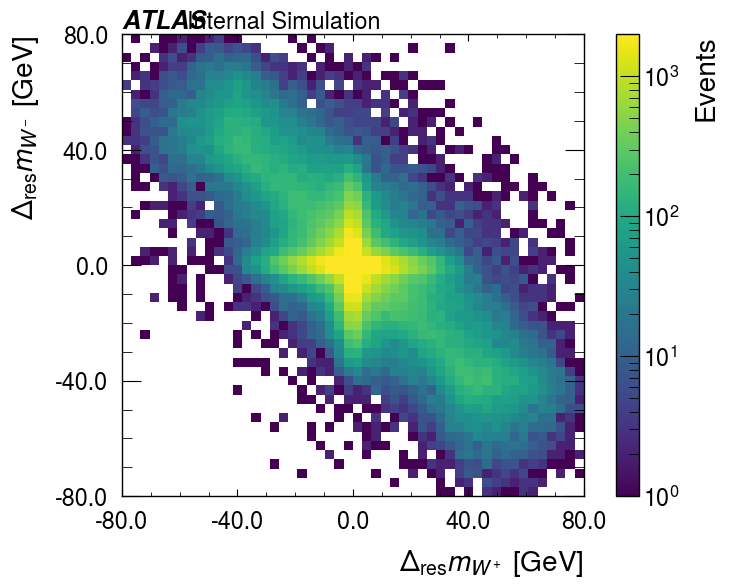

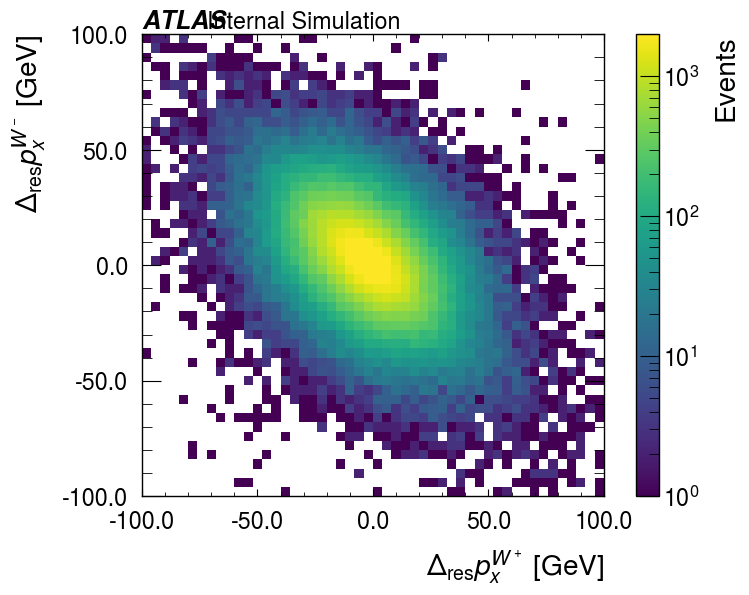

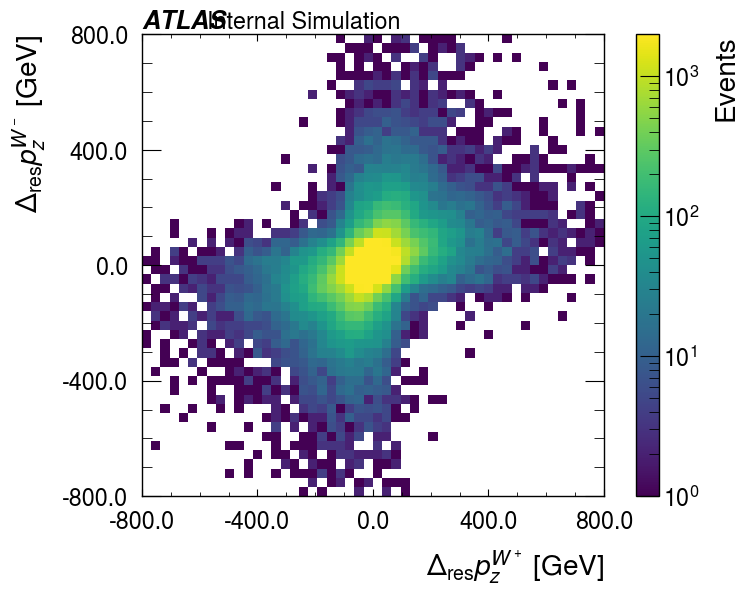

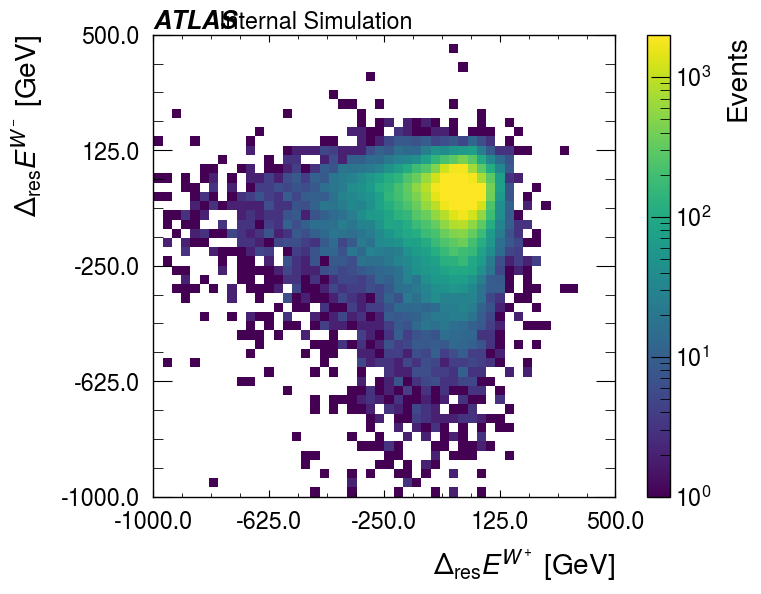

In [19]:
w0_mass_res = pred_w0_mass - true_w0_mass
w1_res = pred_w1_mass - true_w1_mass
plot_2d_res_hist(w0_mass_res, w1_res, name_pos=r"$m_{W^+}$", name_neg=r"$m_{W^-}$", bins_edges=np.linspace(-80, 80, 51), log=True, unit="GeV", color="black", vmax=2e3)

w0_px_res = pred_w0_px - true_w0_px
w1_px_res = pred_w1_px - true_w1_px
plot_2d_res_hist(w0_px_res, w1_px_res, name_pos=r"$p_x^{W^+}$", name_neg=r"$p_x^{W^-}$", bins_edges=np.linspace(-100, 100, 51), log=True, unit="GeV", color="black", vmax=2e3)

w0_pz_res = pred_w0_pz - true_w0_pz
w1_pz_res = pred_w1_pz - true_w1_pz
plot_2d_res_hist(w0_pz_res, w1_pz_res, name_pos=r"$p_z^{W^+}$", name_neg=r"$p_z^{W^-}$", bins_edges=np.linspace(-800, 800, 51), log=True, unit="GeV", color="black", vmax=2e3)

w0_energy_res = pred_w0_energy - true_w0_energy
w1_energy_res = pred_w1_energy - true_w1_energy
plot_2d_res_hist(w0_energy_res, w1_energy_res, name_pos=r"$E^{W^+}$", name_neg=r"$E^{W^-}$", bins_edges=np.linspace(-1000, 500, 51), log=True, unit="GeV", color="black", vmax=2e3)

In [20]:
def alpha_func(lep_on_p4, neu_on_p4, lep_off_p4, neu_off_p4):
    
    def _cal_mass(p4):
        return np.sqrt(p4[:, 3]**2 - p4[:, 0]**2 - p4[:, 1]**2 - p4[:, 2]**2)
    
    def _cal_norm(p4):
        return np.sqrt(p4[:, 0]**2 + p4[:, 1]**2 + p4[:, 2]**2)
    
    # dinu_p4 = neu_on_p4 + neu_off_p4
    # dinu_mass = _cal_mass(dinu_p4)
    dinu_lep_on_p4 = lep_on_p4 + neu_on_p4 + neu_off_p4
    dinu_lep_on_mass = _cal_mass(dinu_lep_on_p4)
    dinu_lep_off_p4 = lep_off_p4 + neu_on_p4 + neu_off_p4
    dinu_lep_off_mass = _cal_mass(dinu_lep_off_p4)
        
    alpha = np.where(
        dinu_lep_on_mass > dinu_lep_off_mass,
        _cal_norm(neu_on_p4) / (_cal_norm(neu_on_p4) + _cal_norm(neu_off_p4) + 1e-16),
        _cal_norm(neu_off_p4) / (_cal_norm(neu_on_p4) + _cal_norm(neu_off_p4) + 1e-16)
    )
    
    return alpha

# true
true_w0_p4 = np.stack([true_w0_px, true_w0_py, true_w0_pz, true_w0_energy], axis=-1)
true_w1_p4 = np.stack([true_w1_px, true_w1_py, true_w1_pz, true_w1_energy], axis=-1)
true_lep0_p4 = np.stack([true_lep0_px, true_lep0_py, true_lep0_pz, true_lep0_energy], axis=-1)
true_lep1_p4 = np.stack([true_lep1_px, true_lep1_py, true_lep1_pz, true_lep1_energy], axis=-1)

# pred
pred_w0_p4 = np.stack([pred_w0_px, pred_w0_py, pred_w0_pz, pred_w0_energy], axis=-1)
pred_w1_p4 = np.stack([pred_w1_px, pred_w1_py, pred_w1_pz, pred_w1_energy], axis=-1)

w_mass_con = 80.379 # GeV
w_mass_con_2 = w_mass_con ** 2

true_0_on_mask = np.abs(true_w0_mass_2 - w_mass_con_2) < np.abs(true_w1_mass_2 - w_mass_con_2)
true_lep_on_p4 = np.where(true_0_on_mask[:, np.newaxis], true_lep0_p4, true_lep1_p4)
true_lep_off_p4 = np.where(true_0_on_mask[:, np.newaxis], true_lep1_p4, true_lep0_p4)
true_w_on_p4 = np.where(true_0_on_mask[:, np.newaxis], true_w0_p4, true_w1_p4)
true_w_off_p4 = np.where(true_0_on_mask[:, np.newaxis], true_w1_p4, true_w0_p4)
true_neu_on_p4 = true_w_on_p4 - true_lep_on_p4
true_neu_off_p4 = true_w_off_p4 - true_lep_off_p4

pred_0_on_mask = np.abs(pred_w0_mass_2 - w_mass_con_2) < np.abs(pred_w1_mass_2 - w_mass_con_2)
pred_w_on_p4 = np.where(pred_0_on_mask[:, np.newaxis], pred_w0_p4, pred_w1_p4)
pred_w_off_p4 = np.where(pred_0_on_mask[:, np.newaxis], pred_w1_p4, pred_w0_p4)
pred_neu_on_p4 = pred_w_on_p4 - true_lep_on_p4
pred_neu_off_p4 = pred_w_off_p4 - true_lep_off_p4

true_alpha = alpha_func(true_lep_on_p4, true_neu_on_p4, true_lep_off_p4, true_neu_off_p4)
pred_alpha = alpha_func(true_lep_on_p4, pred_neu_on_p4, true_lep_off_p4, pred_neu_off_p4)

/tmp/ipykernel_373643/4229498418.py:4: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(p4[:, 3]**2 - p4[:, 0]**2 - p4[:, 1]**2 - p4[:, 2]**2)


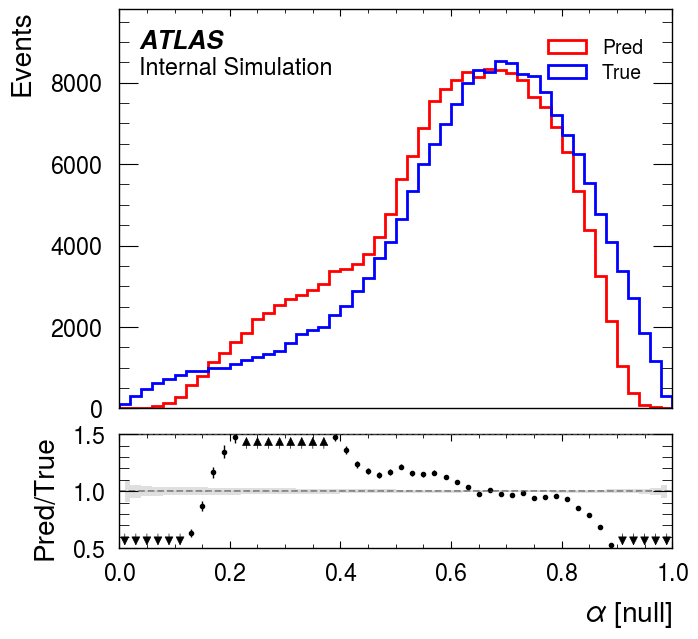

Rel err < 20%: 44.33 %


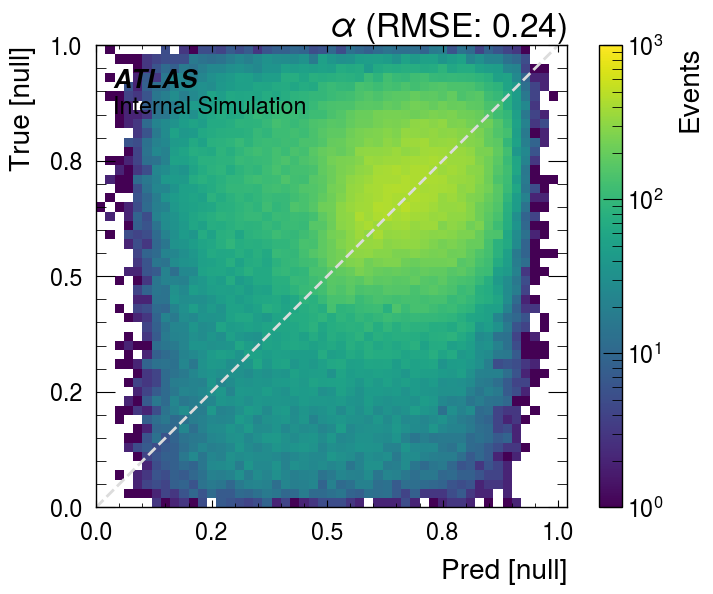

In [21]:
plot_1d_hist(pred_alpha, true_alpha, r"$\alpha$", np.linspace(0, 1, 51), unit="null")
plot_2d_hist(pred_alpha, true_alpha, r"$\alpha$", np.linspace(0, 1, 51), log=True, unit="null", color="black", vmax=1e3)

In [22]:
lep_p4 = np.concatenate([true_lep0_p4, true_lep1_p4], axis=1)
true_w_p4 = np.concatenate([true_w0_p4, true_w1_p4], axis=1)
pred_w_p4 = np.concatenate([pred_w0_p4, pred_w1_p4], axis=1)

def angular_features_like_training(lep_p4, true_w_p4, pred_w_p4, device):
    lep = torch.as_tensor(lep_p4, dtype=torch.float32, device=device)
    true_w = torch.as_tensor(true_w_p4, dtype=torch.float32, device=device)
    pred_w = torch.as_tensor(pred_w_p4, dtype=torch.float32, device=device)

    true_booster = TorchBooster(lep, true_w)
    pred_booster = TorchBooster(lep, pred_w)
    valid = true_booster.valid_rest_frame_mask() & pred_booster.valid_rest_frame_mask()

    true_ang = torch.stack(true_booster.lep_theta_phi_in_w_rest(), dim=-1)[valid]
    pred_ang = torch.stack(pred_booster.lep_theta_phi_in_w_rest(), dim=-1)[valid]
    return true_ang.cpu().numpy(), pred_ang.cpu().numpy(), valid.cpu().numpy()

true_ang, pred_ang, angular_valid = angular_features_like_training(lep_p4, true_w_p4, pred_w_p4, device)
print(f"Angular valid events: {angular_valid.sum()} / {len(angular_valid)}")

# true_l0_theta_phi = (true_ang[:, 0], true_ang[:, 1], true_ang[:, 2])
# true_l1_theta_phi = (true_ang[:, 3], true_ang[:, 4], true_ang[:, 5])
# pred_l0_theta_phi = (pred_ang[:, 0], pred_ang[:, 1], pred_ang[:, 2])
# pred_l1_theta_phi = (pred_ang[:, 3], pred_ang[:, 4], pred_ang[:, 5])
true_l0_theta_phi = (true_ang[:, 0], true_ang[:, 1])
true_l1_theta_phi = (true_ang[:, 2], true_ang[:, 3])
pred_l0_theta_phi = (pred_ang[:, 0], pred_ang[:, 1])
pred_l1_theta_phi = (pred_ang[:, 2], pred_ang[:, 3])


Angular valid events: 185968 / 185968


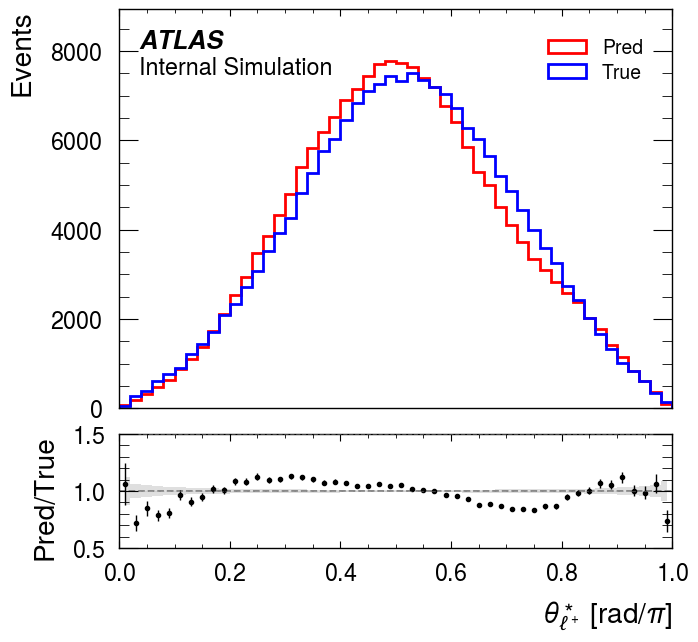

Rel err < 20%: 43.63 %


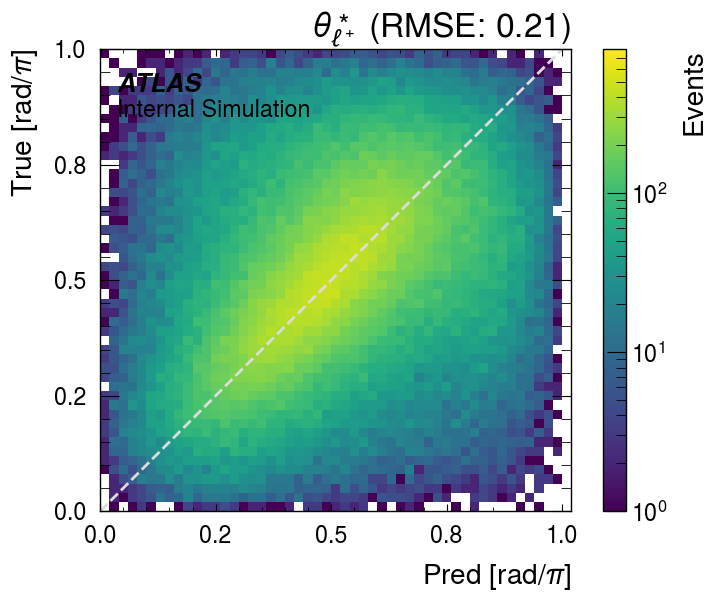

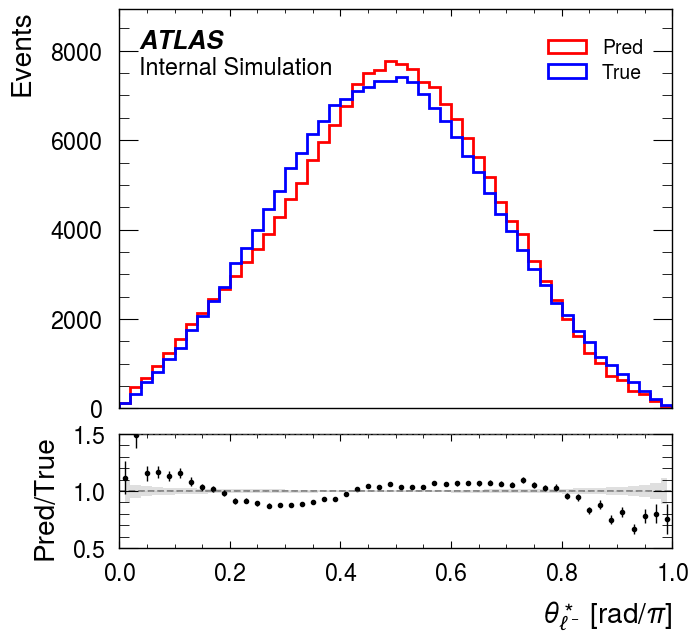

Rel err < 20%: 42.38 %


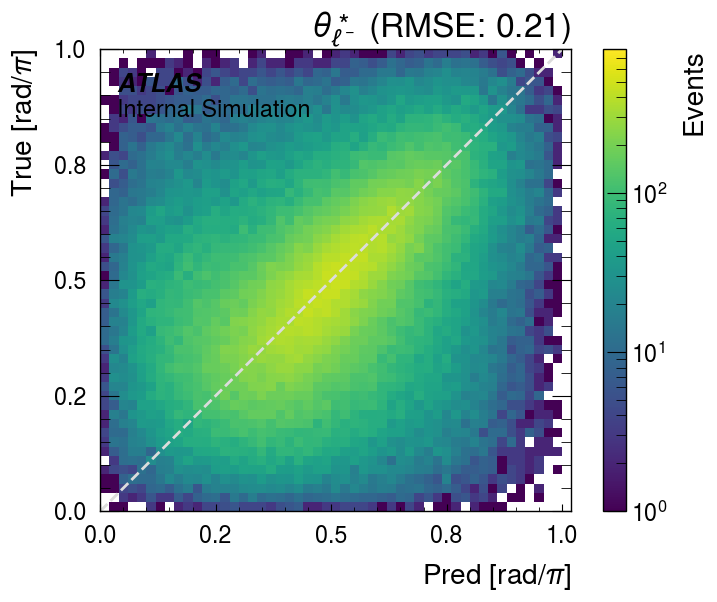

In [23]:
plot_1d_hist(pred_l0_theta_phi[0] / np.pi, true_l0_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l0_theta_phi[0] / np.pi, true_l0_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)
plot_1d_hist(pred_l1_theta_phi[0] / np.pi, true_l1_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l1_theta_phi[0] / np.pi, true_l1_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)

In [24]:
# plot_1d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\sin(\phi^\ast_{\ell^+})$", np.linspace(-1, 1, 61), unit="null")
# plot_2d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\sin(\phi^\ast_{\ell^+})$", np.linspace(-1, 1, 61), log=True, unit="null", color="black", vmax=1e2)
# plot_1d_hist(pred_l0_theta_phi[2], true_l0_theta_phi[2], r"$\cos(\phi^\ast_{\ell^+})$", np.linspace(-1, 1, 61), unit="null")
# plot_2d_hist(pred_l0_theta_phi[2], true_l0_theta_phi[2], r"$\cos(\phi^\ast_{\ell^+})$", np.linspace(-1, 1, 61), log=True, unit="null", color="black", vmax=1e2)

In [25]:
# plot_1d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\sin(\phi^\ast_{\ell^-})$", np.linspace(-1, 1, 61), unit="null")
# plot_2d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\sin(\phi^\ast_{\ell^-})$", np.linspace(-1, 1, 61), log=True, unit="null", color="black", vmax=1e2)
# plot_1d_hist(pred_l1_theta_phi[2], true_l1_theta_phi[2], r"$\cos(\phi^\ast_{\ell^-})$", np.linspace(-1, 1, 61), unit="null")
# plot_2d_hist(pred_l1_theta_phi[2], true_l1_theta_phi[2], r"$\cos(\phi^\ast_{\ell^-})$", np.linspace(-1, 1, 61), log=True, unit="null", color="black", vmax=1e2)

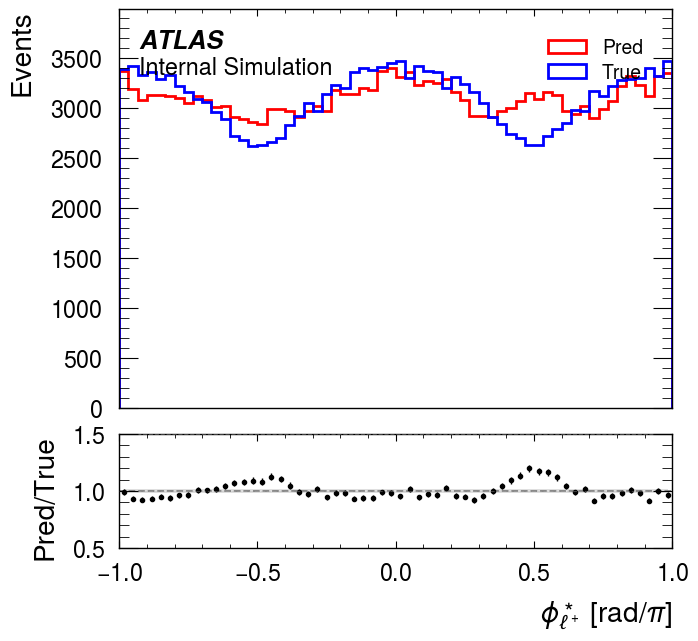

Rel err < 20%: 17.47 %


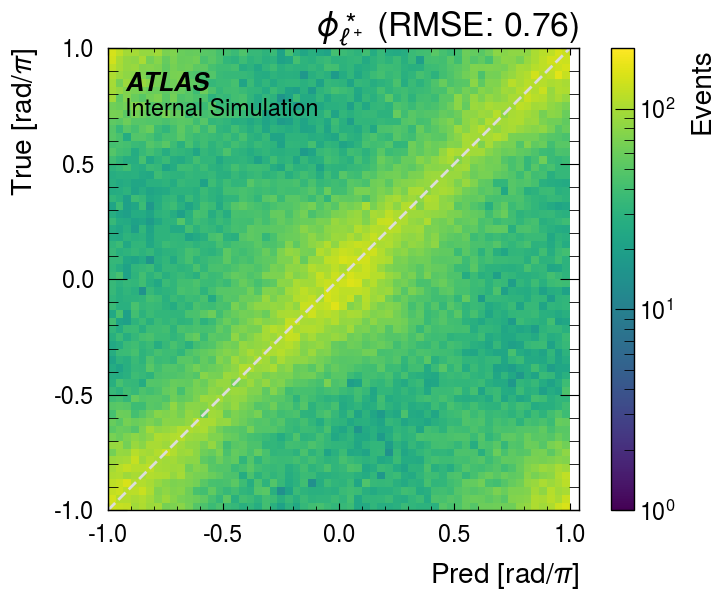

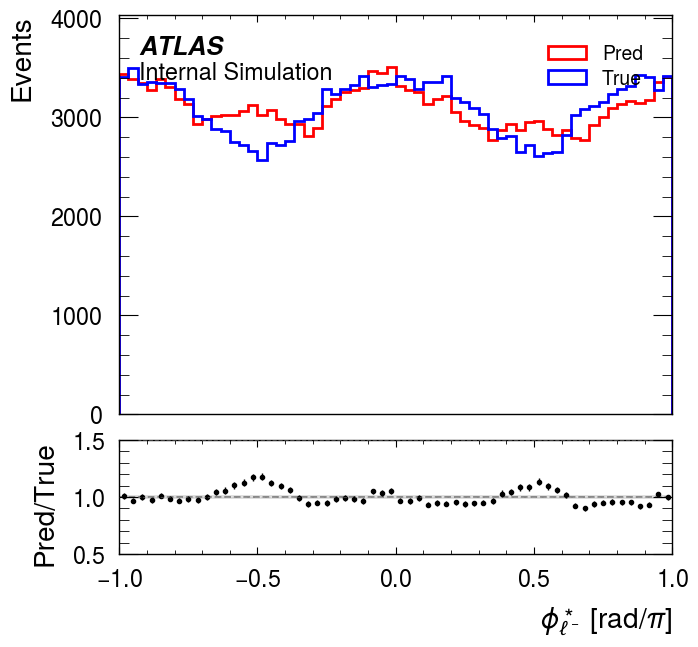

Rel err < 20%: 17.27 %


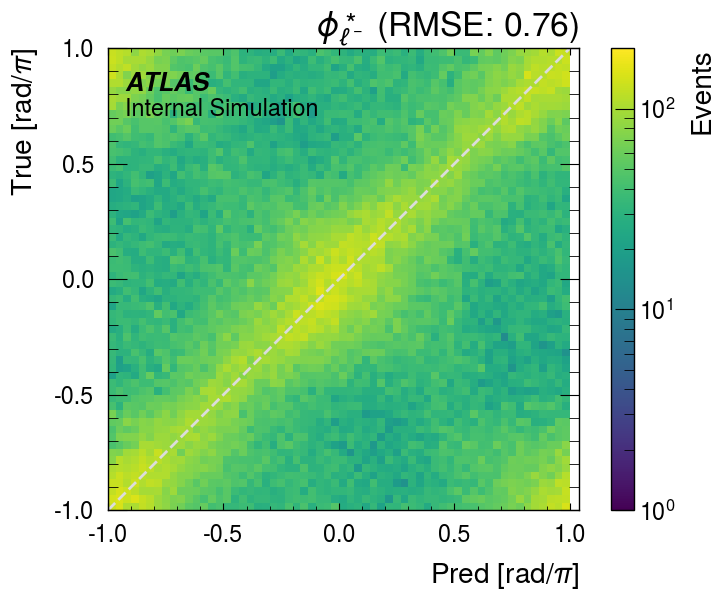

In [26]:
# true_l0_phi = np.arctan2(true_l0_theta_phi[1], true_l0_theta_phi[2])
# true_l1_phi = np.arctan2(true_l1_theta_phi[1], true_l1_theta_phi[2])
# pred_l0_phi = np.arctan2(pred_l0_theta_phi[1], pred_l0_theta_phi[2])
# pred_l1_phi = np.arctan2(pred_l1_theta_phi[1], pred_l1_theta_phi[2])
true_l0_phi = true_l0_theta_phi[1]
true_l1_phi = true_l1_theta_phi[1]
pred_l0_phi = pred_l0_theta_phi[1]
pred_l1_phi = pred_l1_theta_phi[1]

plot_1d_hist(pred_l0_phi / np.pi, true_l0_phi / np.pi, r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 61), unit="rad/$\pi$")
plot_2d_hist(pred_l0_phi / np.pi, true_l0_phi / np.pi, r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 61), log=True, unit="rad/$\pi$", color="black", vmax=2e2)
plot_1d_hist(pred_l1_phi / np.pi, true_l1_phi / np.pi, r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 61), unit="rad/$\pi$")
plot_2d_hist(pred_l1_phi / np.pi, true_l1_phi / np.pi, r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 61), log=True, unit="rad/$\pi$", color="black", vmax=2e2)

In [27]:
# sum and diff of theta
sum_theta_pred = pred_l0_theta_phi[0] + pred_l1_theta_phi[0]
sum_theta_true = true_l0_theta_phi[0] + true_l1_theta_phi[0]
diff_theta_pred = pred_l0_theta_phi[0] - pred_l1_theta_phi[0]
diff_theta_true = true_l0_theta_phi[0] - true_l1_theta_phi[0]
# plot_1d_hist(sum_theta_pred / np.pi, sum_theta_true / np.pi, r"$\sum_{+-}{\theta^\ast_{\ell}}$", np.linspace(0, 2, 51), unit="rad/$\pi$")
# plot_2d_hist(sum_theta_pred / np.pi, sum_theta_true / np.pi, r"$\sum_{+-}{\theta^\ast_{\ell}}$", np.linspace(0, 2, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)
# plot_1d_hist(diff_theta_pred / np.pi, diff_theta_true / np.pi, r"$\Delta_{+-}\theta^\ast_{\ell}$", np.linspace(-1, 1, 61), unit="rad/$\pi$")
# plot_2d_hist(diff_theta_pred / np.pi, diff_theta_true / np.pi, r"$\Delta_{+-}\theta^\ast_{\ell}$", np.linspace(-1, 1, 61), log=True, unit="rad/$\pi$", color="black", vmax=8e2)

In [28]:
# sum and diff of phi
sum_phi_pred = sphi(pred_l0_theta_phi[1], pred_l1_theta_phi[1])
sum_phi_true = sphi(true_l0_theta_phi[1], true_l1_theta_phi[1])
diff_phi_pred = dphi(pred_l0_theta_phi[1], pred_l1_theta_phi[1])
diff_phi_true = dphi(true_l0_theta_phi[1], true_l1_theta_phi[1])
# plot_1d_hist(sum_phi_pred / np.pi, sum_phi_true / np.pi, r"$\sum_{+-}{\phi^\ast_{\ell}}$", np.linspace(-1, 1, 61), unit="rad/$\pi$")
# plot_2d_hist(sum_phi_pred / np.pi, sum_phi_true / np.pi, r"$\sum_{+-}{\phi^\ast_{\ell}}$", np.linspace(-1, 1, 61), log=False, unit="rad/$\pi$", color="lightgray", vmax=3e2)
# plot_1d_hist(diff_phi_pred / np.pi, diff_phi_true / np.pi, r"$\Delta_{+-}\phi^\ast_{\ell}$", np.linspace(-1, 1, 61), unit="rad/$\pi$")
# plot_2d_hist(diff_phi_pred / np.pi, diff_phi_true / np.pi, r"$\Delta_{+-}\phi^\ast_{\ell}$", np.linspace(-1, 1, 61), log=False, unit="rad/$\pi$", color="lightgray", vmax=3e2)

In [29]:
# sum of theta_phi
sum_theta_pos_phi_pos_pred = sphi(pred_l0_theta_phi[0], pred_l0_theta_phi[1])
sum_theta_pos_phi_pos_true = sphi(true_l0_theta_phi[0], true_l0_theta_phi[1])
sum_theta_pos_phi_neg_pred = sphi(pred_l0_theta_phi[0], pred_l1_theta_phi[1])
sum_theta_pos_phi_neg_true = sphi(true_l0_theta_phi[0], true_l1_theta_phi[1])
sum_theta_neg_phi_pos_pred = sphi(pred_l1_theta_phi[0], pred_l0_theta_phi[1])
sum_theta_neg_phi_pos_true = sphi(true_l1_theta_phi[0], true_l0_theta_phi[1])
sum_theta_neg_phi_neg_pred = sphi(pred_l1_theta_phi[0], pred_l1_theta_phi[1])
sum_theta_neg_phi_neg_true = sphi(true_l1_theta_phi[0], true_l1_theta_phi[1])

# plot_1d_hist(sum_theta_pos_phi_pos_pred / np.pi, sum_theta_pos_phi_pos_true / np.pi, r"$\sum_{++}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(sum_theta_pos_phi_pos_pred / np.pi, sum_theta_pos_phi_pos_true / np.pi, r"$\sum_{++}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)
# plot_1d_hist(sum_theta_pos_phi_neg_pred / np.pi, sum_theta_pos_phi_neg_true / np.pi, r"$\sum_{+-}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(sum_theta_pos_phi_neg_pred / np.pi, sum_theta_pos_phi_neg_true / np.pi, r"$\sum_{+-}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)
# plot_1d_hist(sum_theta_neg_phi_pos_pred / np.pi, sum_theta_neg_phi_pos_true / np.pi, r"$\sum_{--}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(sum_theta_neg_phi_pos_pred / np.pi, sum_theta_neg_phi_pos_true / np.pi, r"$\sum_{--}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)
# plot_1d_hist(sum_theta_neg_phi_neg_pred / np.pi, sum_theta_neg_phi_neg_true / np.pi, r"$\sum_{--}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(sum_theta_neg_phi_neg_pred / np.pi, sum_theta_neg_phi_neg_true / np.pi, r"$\sum_{--}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)

In [30]:
# diff of theta_phi
diff_theta_pos_phi_pos_pred = dphi(pred_l0_theta_phi[0], pred_l0_theta_phi[1])
diff_theta_pos_phi_pos_true = dphi(true_l0_theta_phi[0], true_l0_theta_phi[1])
diff_theta_pos_phi_neg_pred = dphi(pred_l0_theta_phi[0], pred_l1_theta_phi[1])
diff_theta_pos_phi_neg_true = dphi(true_l0_theta_phi[0], true_l1_theta_phi[1])
diff_theta_neg_phi_pos_pred = dphi(pred_l1_theta_phi[0], pred_l0_theta_phi[1])
diff_theta_neg_phi_pos_true = dphi(true_l1_theta_phi[0], true_l0_theta_phi[1])
diff_theta_neg_phi_neg_pred = dphi(pred_l1_theta_phi[0], pred_l1_theta_phi[1])
diff_theta_neg_phi_neg_true = dphi(true_l1_theta_phi[0], true_l1_theta_phi[1])

# plot_1d_hist(diff_theta_pos_phi_pos_pred / np.pi, diff_theta_pos_phi_pos_true / np.pi, r"$\Delta_{++}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(diff_theta_pos_phi_pos_pred / np.pi, diff_theta_pos_phi_pos_true / np.pi, r"$\Delta_{++}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)
# plot_1d_hist(diff_theta_pos_phi_neg_pred / np.pi, diff_theta_pos_phi_neg_true / np.pi, r"$\Delta_{+-}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(diff_theta_pos_phi_neg_pred / np.pi, diff_theta_pos_phi_neg_true / np.pi, r"$\Delta_{+-}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)
# plot_1d_hist(diff_theta_neg_phi_pos_pred / np.pi, diff_theta_neg_phi_pos_true / np.pi, r"$\Delta_{--}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(diff_theta_neg_phi_pos_pred / np.pi, diff_theta_neg_phi_pos_true / np.pi, r"$\Delta_{--}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)
# plot_1d_hist(diff_theta_neg_phi_neg_pred / np.pi, diff_theta_neg_phi_neg_true / np.pi, r"$\Delta_{--}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(diff_theta_neg_phi_neg_pred / np.pi, diff_theta_neg_phi_neg_true / np.pi, r"$\Delta_{--}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)

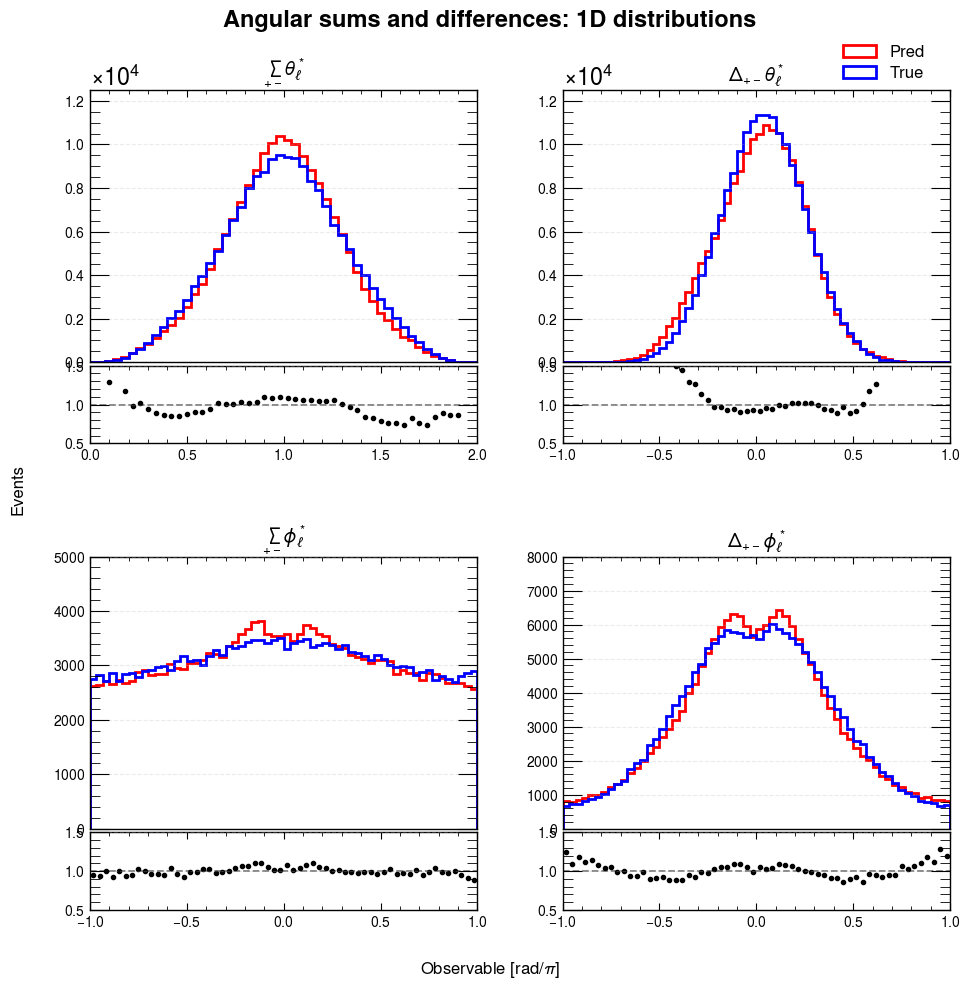

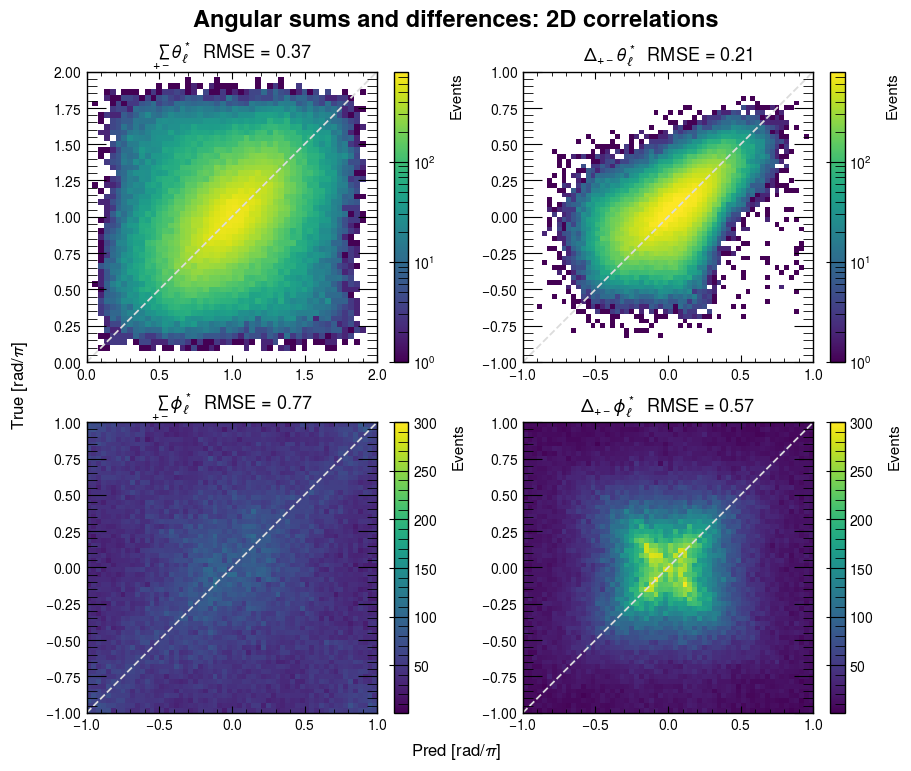

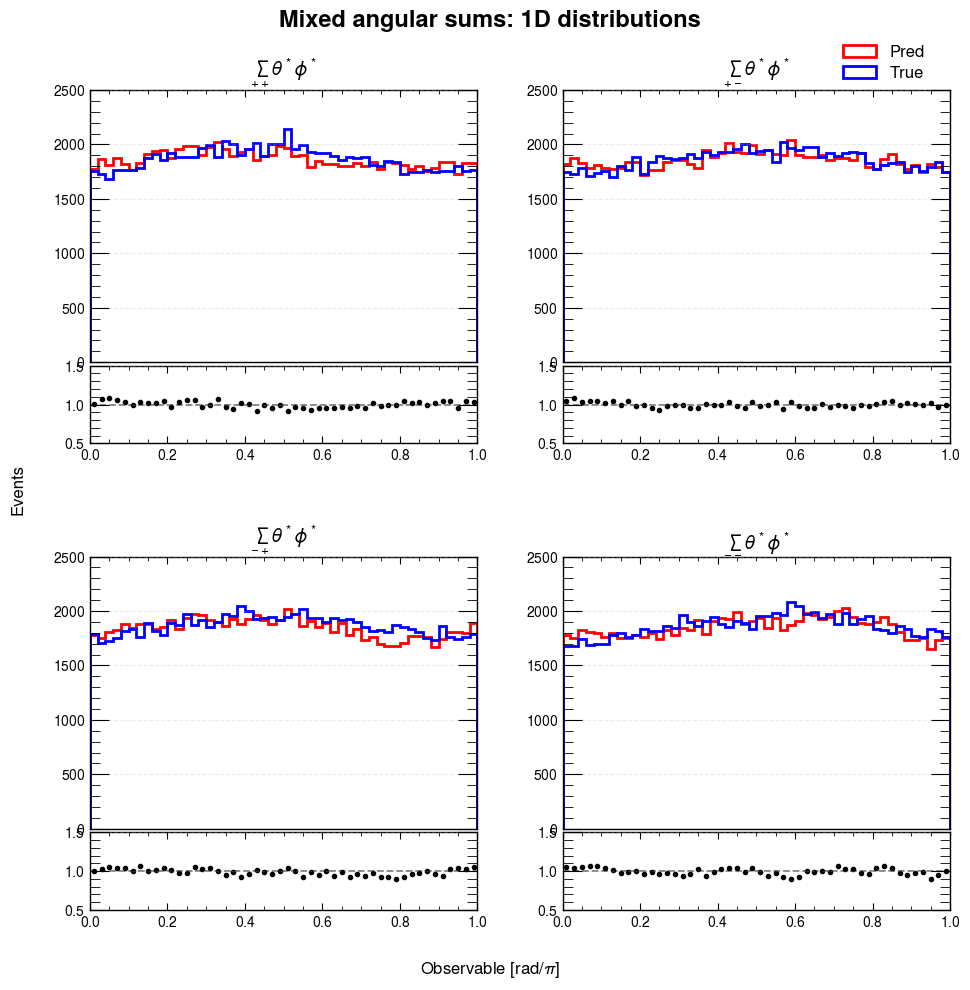

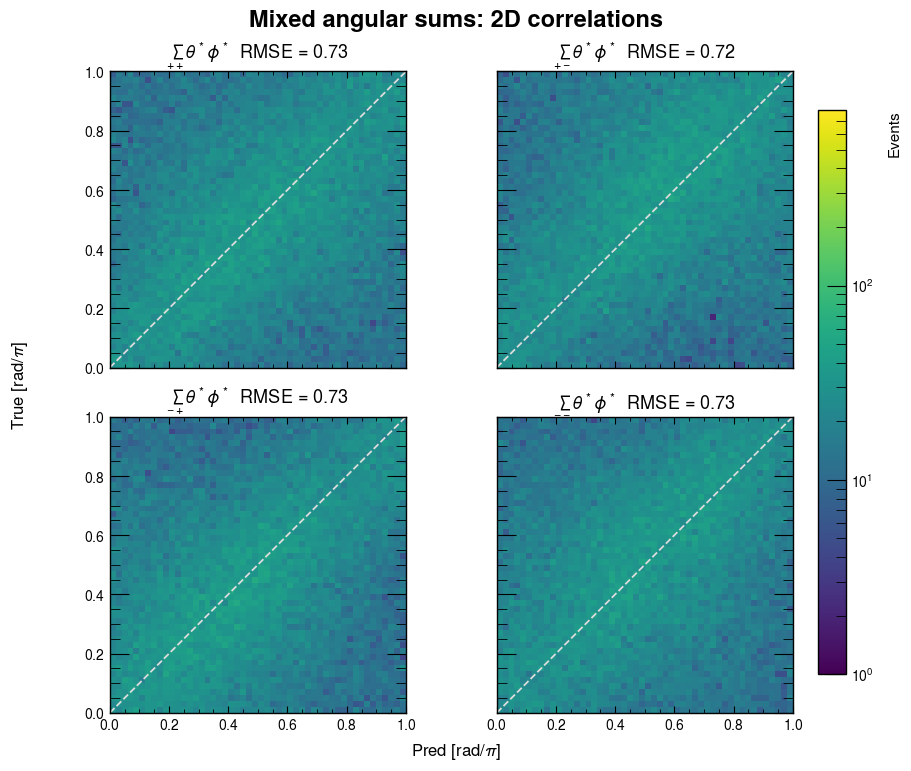

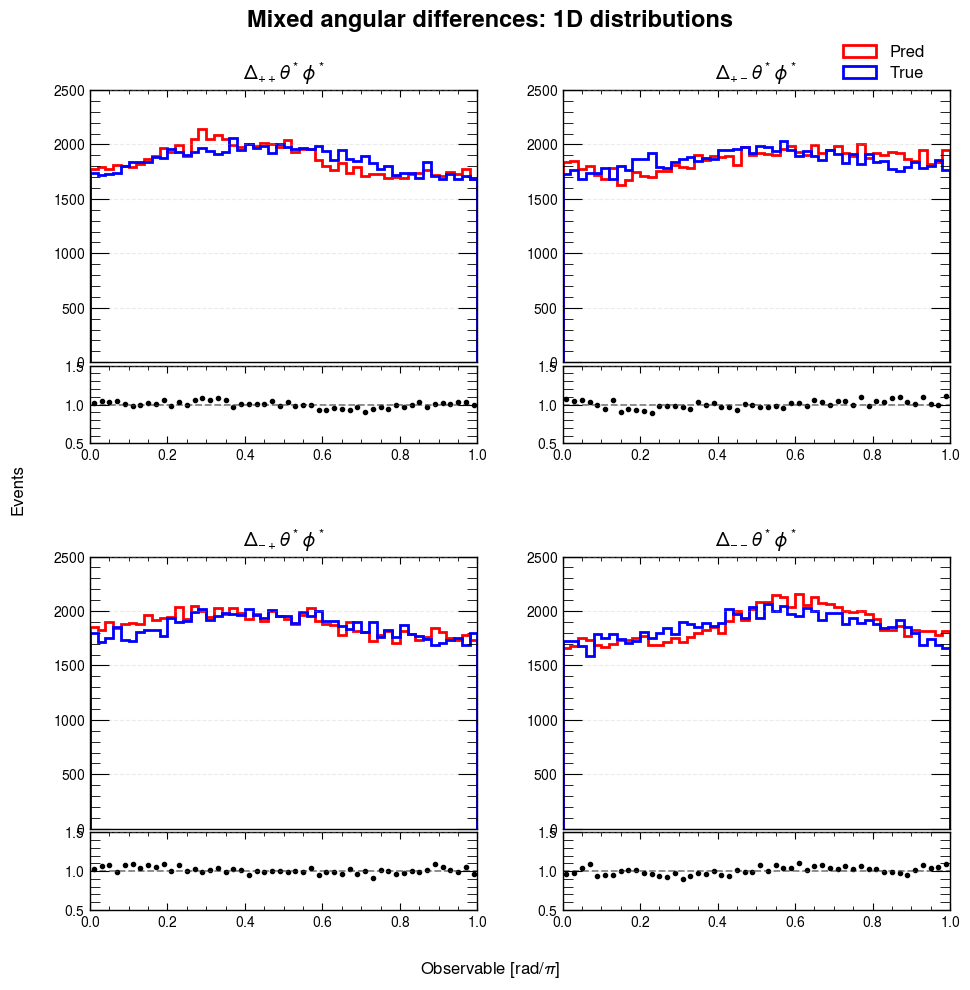

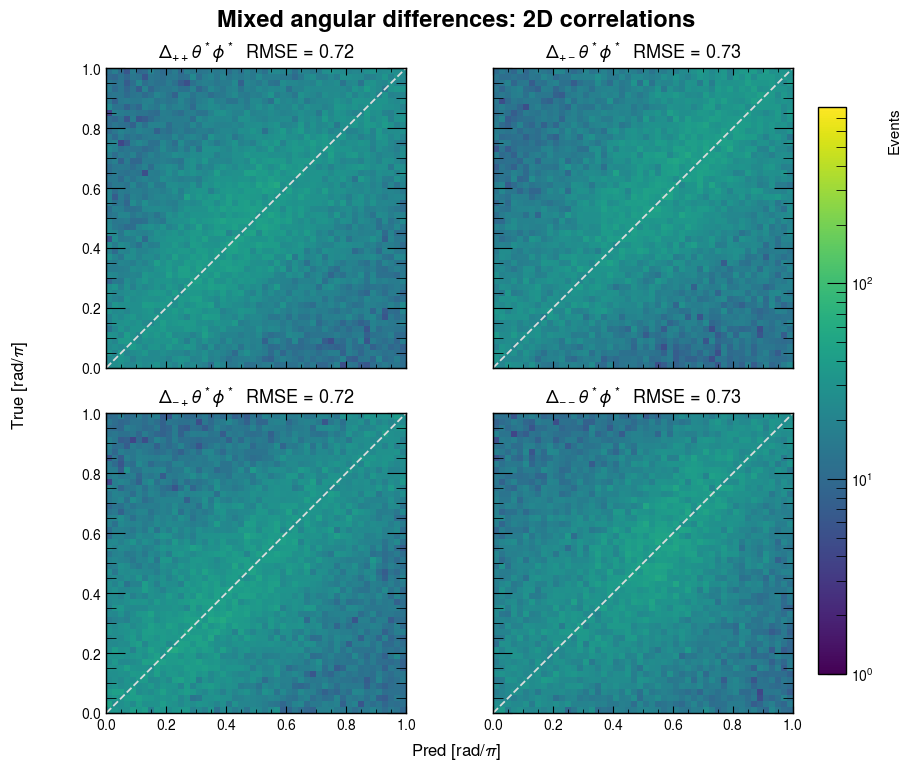

In [31]:
angular_observables = [
    {"pred": sum_theta_pred, "truth": sum_theta_true, "label": r"$\sum_{+-}\theta^*_{\ell}$", "bins": np.linspace(0, 2, 51), "log": True, "vmax": 8e2},
    {"pred": diff_theta_pred, "truth": diff_theta_true, "label": r"$\Delta_{+-}\theta^*_{\ell}$", "bins": np.linspace(-1, 1, 61), "log": True, "vmax": 8e2},
    {"pred": sum_phi_pred, "truth": sum_phi_true, "label": r"$\sum_{+-}\phi^*_{\ell}$", "bins": np.linspace(-1, 1, 61), "log": False, "vmax": 3e2},
    {"pred": diff_phi_pred, "truth": diff_phi_true, "label": r"$\Delta_{+-}\phi^*_{\ell}$", "bins": np.linspace(-1, 1, 61), "log": False, "vmax": 3e2},
]

mixed_sum_observables = [
    {"pred": sum_theta_pos_phi_pos_pred, "truth": sum_theta_pos_phi_pos_true, "label": r"$\sum_{++}\theta^*\phi^*$", "bins": np.linspace(0, 1, 51), "log": True, "vmax": 8e2},
    {"pred": sum_theta_pos_phi_neg_pred, "truth": sum_theta_pos_phi_neg_true, "label": r"$\sum_{+-}\theta^*\phi^*$", "bins": np.linspace(0, 1, 51), "log": True, "vmax": 8e2},
    {"pred": sum_theta_neg_phi_pos_pred, "truth": sum_theta_neg_phi_pos_true, "label": r"$\sum_{-+}\theta^*\phi^*$", "bins": np.linspace(0, 1, 51), "log": True, "vmax": 8e2},
    {"pred": sum_theta_neg_phi_neg_pred, "truth": sum_theta_neg_phi_neg_true, "label": r"$\sum_{--}\theta^*\phi^*$", "bins": np.linspace(0, 1, 51), "log": True, "vmax": 8e2},
]

mixed_diff_observables = [
    {"pred": diff_theta_pos_phi_pos_pred, "truth": diff_theta_pos_phi_pos_true, "label": r"$\Delta_{++}\theta^*\phi^*$", "bins": np.linspace(0, 1, 51), "log": True, "vmax": 8e2},
    {"pred": diff_theta_pos_phi_neg_pred, "truth": diff_theta_pos_phi_neg_true, "label": r"$\Delta_{+-}\theta^*\phi^*$", "bins": np.linspace(0, 1, 51), "log": True, "vmax": 8e2},
    {"pred": diff_theta_neg_phi_pos_pred, "truth": diff_theta_neg_phi_pos_true, "label": r"$\Delta_{-+}\theta^*\phi^*$", "bins": np.linspace(0, 1, 51), "log": True, "vmax": 8e2},
    {"pred": diff_theta_neg_phi_neg_pred, "truth": diff_theta_neg_phi_neg_true, "label": r"$\Delta_{--}\theta^*\phi^*$", "bins": np.linspace(0, 1, 51), "log": True, "vmax": 8e2},
]

angular_1d_fig, angular_1d_axes = plot_angular_1d_grid(angular_observables, "Angular sums and differences: 1D distributions")
angular_2d_fig, angular_2d_axes = plot_angular_2d_grid(angular_observables, "Angular sums and differences: 2D correlations")
mixed_sum_1d_fig, mixed_sum_1d_axes = plot_angular_1d_grid(mixed_sum_observables, "Mixed angular sums: 1D distributions", share_axes=True)
mixed_sum_2d_fig, mixed_sum_2d_axes = plot_angular_2d_grid(mixed_sum_observables, "Mixed angular sums: 2D correlations", shared_colorbar=True, share_axes=True)
mixed_diff_1d_fig, mixed_diff_1d_axes = plot_angular_1d_grid(mixed_diff_observables, "Mixed angular differences: 1D distributions", share_axes=True)
mixed_diff_2d_fig, mixed_diff_2d_axes = plot_angular_2d_grid(mixed_diff_observables, "Mixed angular differences: 2D correlations", shared_colorbar=True, share_axes=True)

In [32]:
# lep_p4 = np.concatenate([true_lep0_p4, true_lep1_p4], axis=1)
# true_w_p4 = np.concatenate([true_w0_p4, true_w1_p4], axis=1)
# pred_w_p4 = np.concatenate([corr_pred_w0_p4, corr_pred_w1_p4], axis=1)

# def angular_features_like_training(lep_p4, true_w_p4, pred_w_p4, device):
#     lep = torch.as_tensor(lep_p4, dtype=torch.float32, device=device)
#     true_w = torch.as_tensor(true_w_p4, dtype=torch.float32, device=device)
#     pred_w = torch.as_tensor(pred_w_p4, dtype=torch.float32, device=device)

#     true_booster = TorchBooster(lep, true_w)
#     pred_booster = TorchBooster(lep, pred_w)
#     valid = true_booster.valid_rest_frame_mask() & pred_booster.valid_rest_frame_mask()

#     true_ang = torch.stack(true_booster.lep_theta_phi_in_w_rest(), dim=-1)[valid]
#     pred_ang = torch.stack(pred_booster.lep_theta_phi_in_w_rest(), dim=-1)[valid]
#     return true_ang.cpu().numpy(), pred_ang.cpu().numpy(), valid.cpu().numpy()

# true_ang, pred_ang, angular_valid = angular_features_like_training(lep_p4, true_w_p4, pred_w_p4, device)
# print(f"Angular valid events: {angular_valid.sum()} / {len(angular_valid)}")

# # true_l0_theta_phi = (true_ang[:, 0], true_ang[:, 1], true_ang[:, 2])
# # true_l1_theta_phi = (true_ang[:, 3], true_ang[:, 4], true_ang[:, 5])
# # pred_l0_theta_phi = (pred_ang[:, 0], pred_ang[:, 1], pred_ang[:, 2])
# # pred_l1_theta_phi = (pred_ang[:, 3], pred_ang[:, 4], pred_ang[:, 5])
# true_l0_theta_phi = (true_ang[:, 0], true_ang[:, 1])
# true_l1_theta_phi = (true_ang[:, 2], true_ang[:, 3])
# pred_l0_theta_phi = (pred_ang[:, 0], pred_ang[:, 1])
# pred_l1_theta_phi = (pred_ang[:, 2], pred_ang[:, 3])
# # true_l0_phi = np.arctan2(true_l0_theta_phi[1], true_l0_theta_phi[2])
# # true_l1_phi = np.arctan2(true_l1_theta_phi[1], true_l1_theta_phi[2])
# # pred_l0_phi = np.arctan2(pred_l0_theta_phi[1], pred_l0_theta_phi[2])
# # pred_l1_phi = np.arctan2(pred_l1_theta_phi[1], pred_l1_theta_phi[2])
# true_l0_phi = true_l0_theta_phi[1]
# true_l1_phi = true_l1_theta_phi[1]
# pred_l0_phi = pred_l0_theta_phi[1]
# pred_l1_phi = pred_l1_theta_phi[1]

# plot_1d_hist(pred_l0_phi / np.pi, true_l0_phi / np.pi, r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 61), unit="rad/$\pi$")
# plot_2d_hist(pred_l0_phi / np.pi, true_l0_phi / np.pi, r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 61), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
# plot_1d_hist(pred_l1_phi / np.pi, true_l1_phi / np.pi, r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 61), unit="rad/$\pi$")
# plot_2d_hist(pred_l1_phi / np.pi, true_l1_phi / np.pi, r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 61), log=True, unit="rad/$\pi$", color="black", vmax=1e2)


In [33]:
# plot_1d_hist(pred_l0_theta_phi[0] / np.pi, true_l0_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(pred_l0_theta_phi[0] / np.pi, true_l0_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
# plot_1d_hist(pred_l1_theta_phi[0] / np.pi, true_l1_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(pred_l1_theta_phi[0] / np.pi, true_l1_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)

Using metrics file: /root/work/ww-pcres/hww_pcres_regressor_nofold_v61/logs/version_0/metrics.csv
Best loss values at best epoch (min val_loss):
  total: loss=96.983 val_loss=95.5474
  Std $W$ 4-vec Huber: train=0.130971 val=0.131357
  $m_H$ Huber: train=2.63437 val=1.0724
  $\alpha$ MMD: train=0.00554725 val=0.00584442
  Joint $m_W$ MMD: train=0.00458246 val=0.00432296
  $m_W$ Huber: train=0.0441457 val=0.0445134
  Angular MMD: train=0.00520282 val=0.00521435
  $\Delta \mathrm{MET}$: train=0.285254 val=0.285525


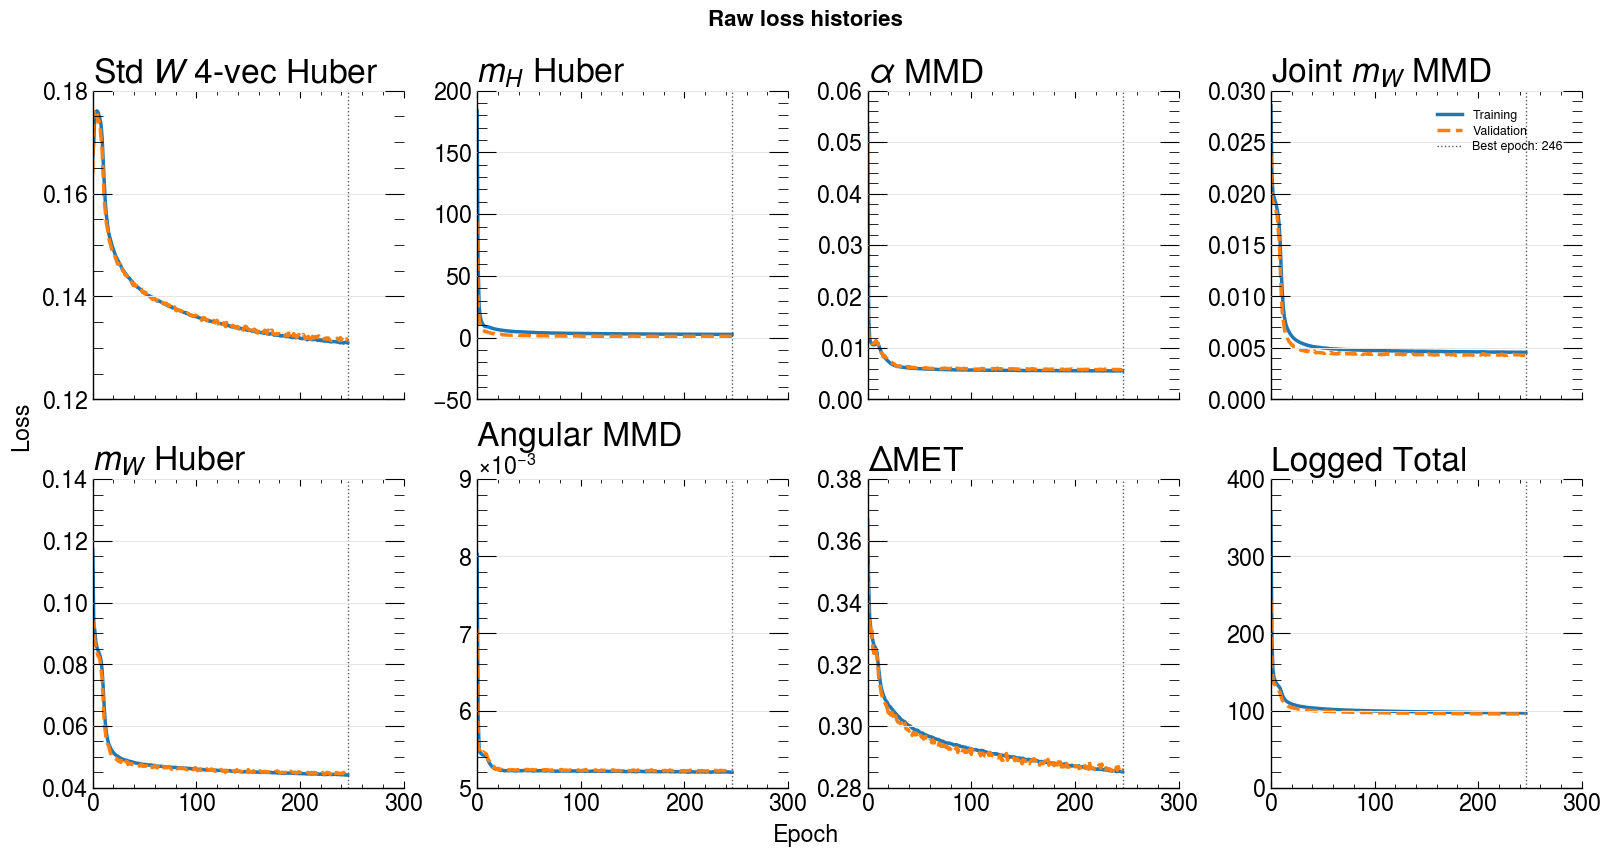

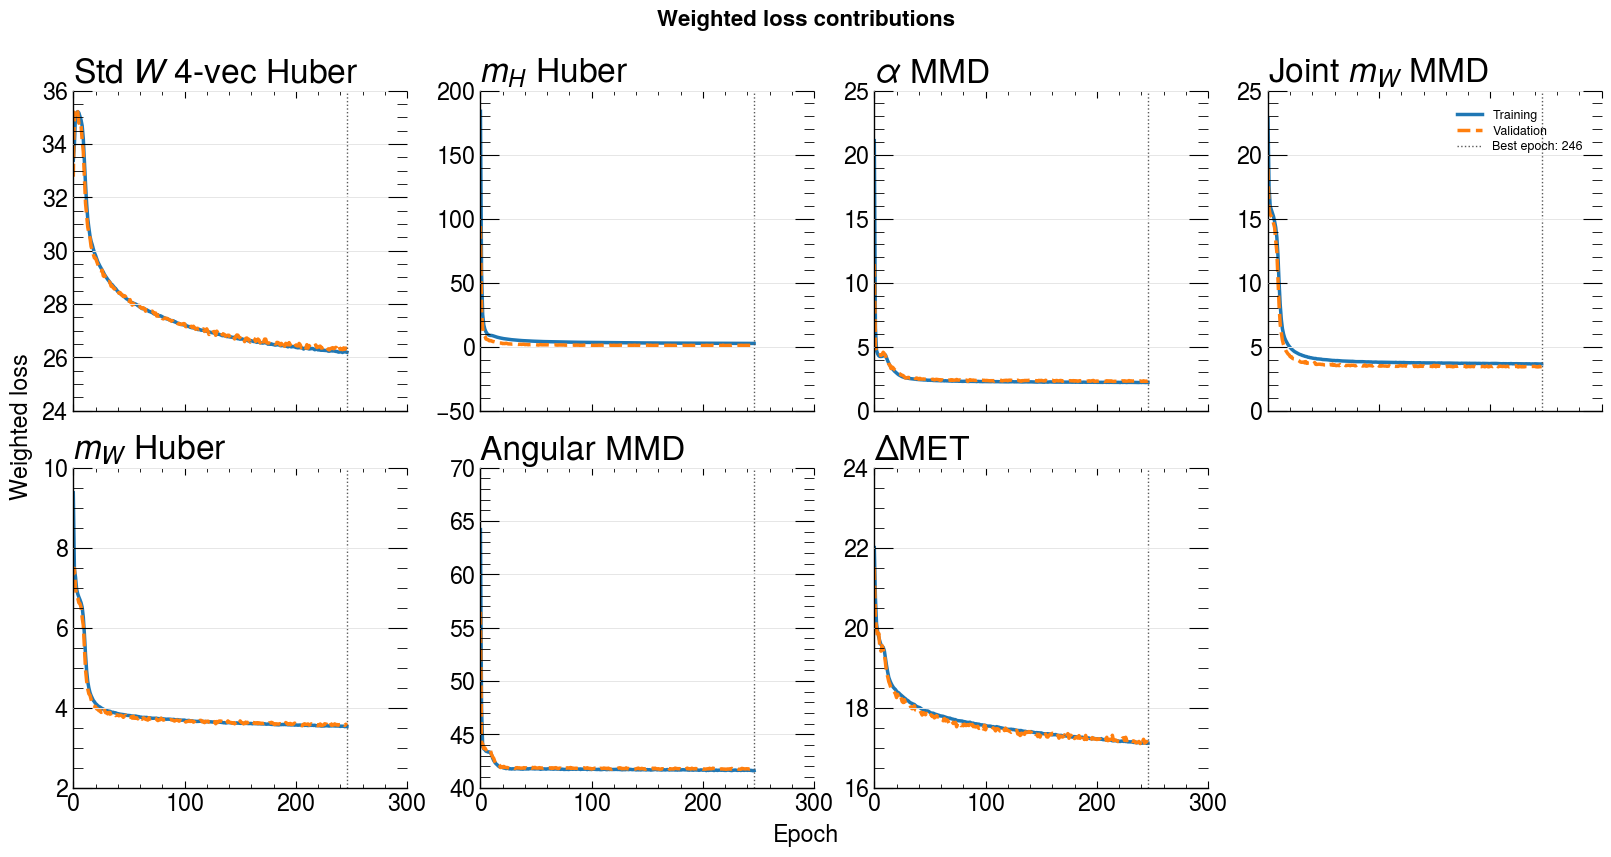

In [34]:
from matplotlib.lines import Line2D


LOSS_COMPONENTS = [
    ("huber", r"Std $W$ 4-vec Huber"),
    ("higgs_mass", r"$m_H$ Huber"),
    ("alpha_mmd", r"$\alpha$ MMD"),
    ("mass_mmd", r"Joint $m_W$ MMD"),
    ("w_mass_huber", r"$m_W$ Huber"),
    ("angular_mmd", "Angular MMD"),
    ("dmet", r"$\Delta \mathrm{MET}$"),
]

DEFAULT_LOSS_WEIGHTS = {
    "huber": 1.0,
    "higgs_mass": 0.0,
    "alpha_mmd": 0.0,
    "mass_mmd": 0.0,
    "w_mass_huber": 0.0,
    "angular_mmd": 0.0,
    "dmet": 0.0,
}


def _metric_series(df, column):
    if "epoch" not in df.columns or column not in df.columns:
        return pd.Series(dtype=float, name=column)
    values = df.loc[df[column].notna() & df["epoch"].notna(), ["epoch", column]]
    values = values.drop_duplicates("epoch", keep="last").sort_values("epoch")
    return values.set_index("epoch")[column]


def _epoch_weights(df, name, epochs, initial_weight):
    result = pd.Series(float(initial_weight), index=epochs, dtype=float, name=name)
    logged = _metric_series(df, f"loss_weight/{name}")
    if logged.empty:
        return result
    combined_epochs = result.index.union(logged.index).sort_values()
    combined = logged.reindex(combined_epochs).ffill().fillna(float(initial_weight))
    return combined.reindex(epochs).rename(name)


def _prepare_loss_plot_data(df, cfg):
    if df.empty:
        raise ValueError("metrics.csv is empty")
    if "epoch" not in df.columns:
        raise ValueError("metrics.csv has no epoch column")

    totals = {
        "train": _metric_series(df, "loss"),
        "val": _metric_series(df, "val_loss"),
    }
    if totals["val"].empty:
        raise ValueError("metrics.csv has no populated val_loss")

    best_epoch = totals["val"].idxmin()
    common_total_epochs = totals["train"].index.intersection(totals["val"].index)
    final_epoch = common_total_epochs.max() if len(common_total_epochs) else None
    params = cfg.get("parameters", {})
    configured_weights = {**DEFAULT_LOSS_WEIGHTS, **params.get("loss_weights", {})}
    raw = {"train": {}, "val": {}}
    weights = {}
    contributions = {"train": {}, "val": {}}
    unavailable = []

    for name, label in LOSS_COMPONENTS:
        train = _metric_series(df, f"{name}_loss")
        val = _metric_series(df, f"val_{name}_loss")
        if train.empty or val.empty:
            unavailable.append(label)
            continue
        raw["train"][name] = train
        raw["val"][name] = val
        component_epochs = (
            totals["train"].index.union(totals["val"].index)
            .union(train.index).union(val.index).sort_values()
        )
        weights[name] = _epoch_weights(
            df,
            name,
            component_epochs,
            configured_weights.get(name, 0.0),
        )
        contributions["train"][name] = train * weights[name].reindex(train.index)
        contributions["val"][name] = val * weights[name].reindex(val.index)

    mismatches = []
    for stage in ("train", "val"):
        if not contributions[stage]:
            continue
        reconstructed = pd.concat(contributions[stage], axis=1).sum(axis=1, min_count=1)
        comparison = pd.concat([reconstructed.rename("reconstructed"), totals[stage]], axis=1).dropna()
        if not comparison.empty and not np.allclose(
            comparison["reconstructed"], comparison[totals[stage].name], rtol=1e-5, atol=1e-8
        ):
            mismatches.append(stage)

    return {
        "totals": totals,
        "best_epoch": best_epoch,
        "final_epoch": final_epoch,
        "raw": raw,
        "weights": weights,
        "contributions": contributions,
        "unavailable": unavailable,
        "mismatches": mismatches,
    }


def _value_at(series, epoch):
    if epoch is None or epoch not in series.index:
        return None
    return float(series.loc[epoch])


def _fmt_value(value):
    return "n/a" if value is None else f"{value:.6g}"


def _top_right_visible_axis(axes):
    visible = [axis for axis in axes if axis.axison]
    return max(visible, key=lambda axis: (axis.get_position().x0, axis.get_position().y1)) if visible else axes[0]


def plot_loss_curves(metrics_path, cfg):
    print(f"Using metrics file: {metrics_path}")
    if not metrics_path.exists():
        print(f"No metrics.csv found at {metrics_path}")
        return None
    try:
        data = _prepare_loss_plot_data(pd.read_csv(metrics_path), cfg)
    except (ValueError, pd.errors.EmptyDataError) as error:
        print(f"Cannot plot losses: {error}")
        return None

    best_epoch = data["best_epoch"]
    print("Best loss values at best epoch (min val_loss):")
    print(
        f"  total: loss={_fmt_value(_value_at(data['totals']['train'], best_epoch))} "
        f"val_loss={_fmt_value(_value_at(data['totals']['val'], best_epoch))}"
    )
    for name, label in LOSS_COMPONENTS:
        if name not in data["raw"]["val"]:
            continue
        train = _fmt_value(_value_at(data["raw"]["train"][name], best_epoch))
        val = _fmt_value(_value_at(data["raw"]["val"][name], best_epoch))
        print(f"  {label}: train={train} val={val}")
    fig_raw, raw_axes = plt.subplots(
        2, 4, figsize=(16, 8.5), sharex=True, layout="constrained"
    )
    fig_weighted, weighted_axes = plt.subplots(
        2, 4, figsize=(16, 8.5), sharex=True, layout="constrained"
    )
    raw_axes = raw_axes.ravel()
    weighted_axes = weighted_axes.ravel()
    stages = (
        ("train", "Training", "tab:blue", "-"),
        ("val", "Validation", "tab:orange", "--"),
    )

    visible_raw_axes = []
    visible_weighted_axes = []
    for index, (name, label) in enumerate(LOSS_COMPONENTS):
        raw_axis = raw_axes[index]
        weighted_axis = weighted_axes[index]
        if name not in data["raw"]["train"]:
            raw_axis.set_axis_off()
            weighted_axis.set_axis_off()
            continue
        for stage, _, color, linestyle in stages:
            raw_series = data["raw"][stage][name]
            raw_axis.plot(
                raw_series.index, raw_series.values, color=color,
                linestyle=linestyle, linewidth=2.5, label=f"{name}:{stage}",
            )
            contribution = data["contributions"][stage][name]
            weighted_axis.plot(
                contribution.index, contribution.values, color=color,
                linestyle=linestyle, linewidth=2.5, label=f"{name}:{stage}",
            )
        raw_axis.set_title(label, loc="left")
        weighted_axis.set_title(label, loc="left")
        visible_raw_axes.append(raw_axis)
        visible_weighted_axes.append(weighted_axis)

    total_axis = raw_axes[len(LOSS_COMPONENTS)]
    for stage, _, color, linestyle in stages:
        total = data["totals"][stage]
        total_axis.plot(
            total.index, total.values, color=color, linestyle=linestyle,
            linewidth=2.5, label=f"total:{stage}",
        )
    total_axis.set_title("Logged Total", loc="left")
    visible_raw_axes.append(total_axis)
    for axis in weighted_axes[len(LOSS_COMPONENTS):]:
        axis.set_axis_off()

    stage_handles = [
        Line2D([0], [0], color=color, linestyle=linestyle, linewidth=2.5, label=label)
        for _, label, color, linestyle in stages
    ]
    stage_handles.append(
        Line2D([0], [0], color="0.35", linestyle=":", linewidth=1,
               label=f"Best epoch: {best_epoch:g}")
    )
    raw_legend_axis = _top_right_visible_axis(raw_axes)
    weighted_legend_axis = _top_right_visible_axis(weighted_axes)

    for figure, axes, title, ylabel, legend_axis in (
        (fig_raw, visible_raw_axes, "Raw loss histories", "Loss", raw_legend_axis),
        (fig_weighted, visible_weighted_axes, "Weighted loss contributions", "Weighted loss", weighted_legend_axis),
    ):
        for axis in axes:
            axis.axvline(
                best_epoch, color="0.35", linestyle=":", linewidth=1,
                label="best_epoch",
            )
            # axis.set_yscale("log", base=10)
            axis.set_yscale("linear")
            axis.ticklabel_format(
                axis="y", style="sci", scilimits=(-3, 4), useMathText=True
            )
            axis.grid(axis="y", color="0.9", linewidth=0.7)
            axis.spines[["top", "right"]].set_visible(False)
        figure.get_layout_engine().set(rect=(0.0, 0.0, 1.0, 0.94))
        figure.suptitle(title, fontsize=16, fontweight="semibold", y=0.99)
        figure.supxlabel("Epoch")
        figure.supylabel(ylabel)
        legend_axis.legend(
            handles=stage_handles, frameon=False, loc="upper right", fontsize=9,
        )

    if data["unavailable"]:
        print("Unavailable train/validation pairs: " + ", ".join(data["unavailable"]))
    if data["mismatches"]:
        display_stages = ["validation" if stage == "val" else stage for stage in data["mismatches"]]
        print(
            "Warning: weighted contributions could not be reconstructed exactly for: "
            + ", ".join(display_stages)
            + ". Logger timing or aggregation may differ from epoch reconstruction."
        )

    plt.show()
    data["figures"] = [fig_raw, fig_weighted]
    return data


if "LOG_DIR" not in globals():
    log_dirs = sorted(
        (RUN_DIR / "logs").glob("version_*"),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    LOG_DIR = log_dirs[0] if log_dirs else None

if LOG_DIR is None:
    print("No logs found.")
else:
    loss_diagnostics = plot_loss_curves(LOG_DIR / "metrics.csv", cfg)


No populated pairwise grad_cos metrics found.


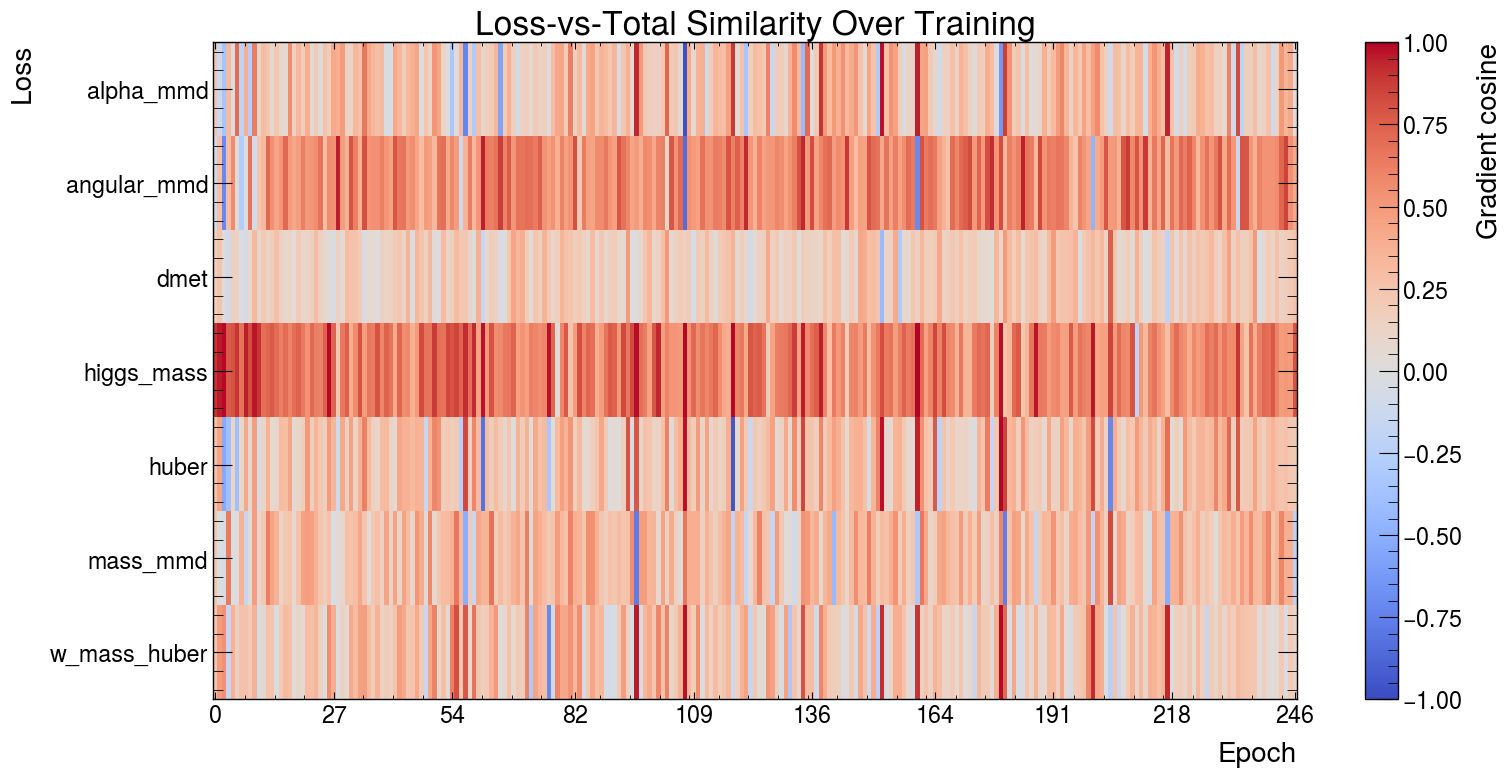

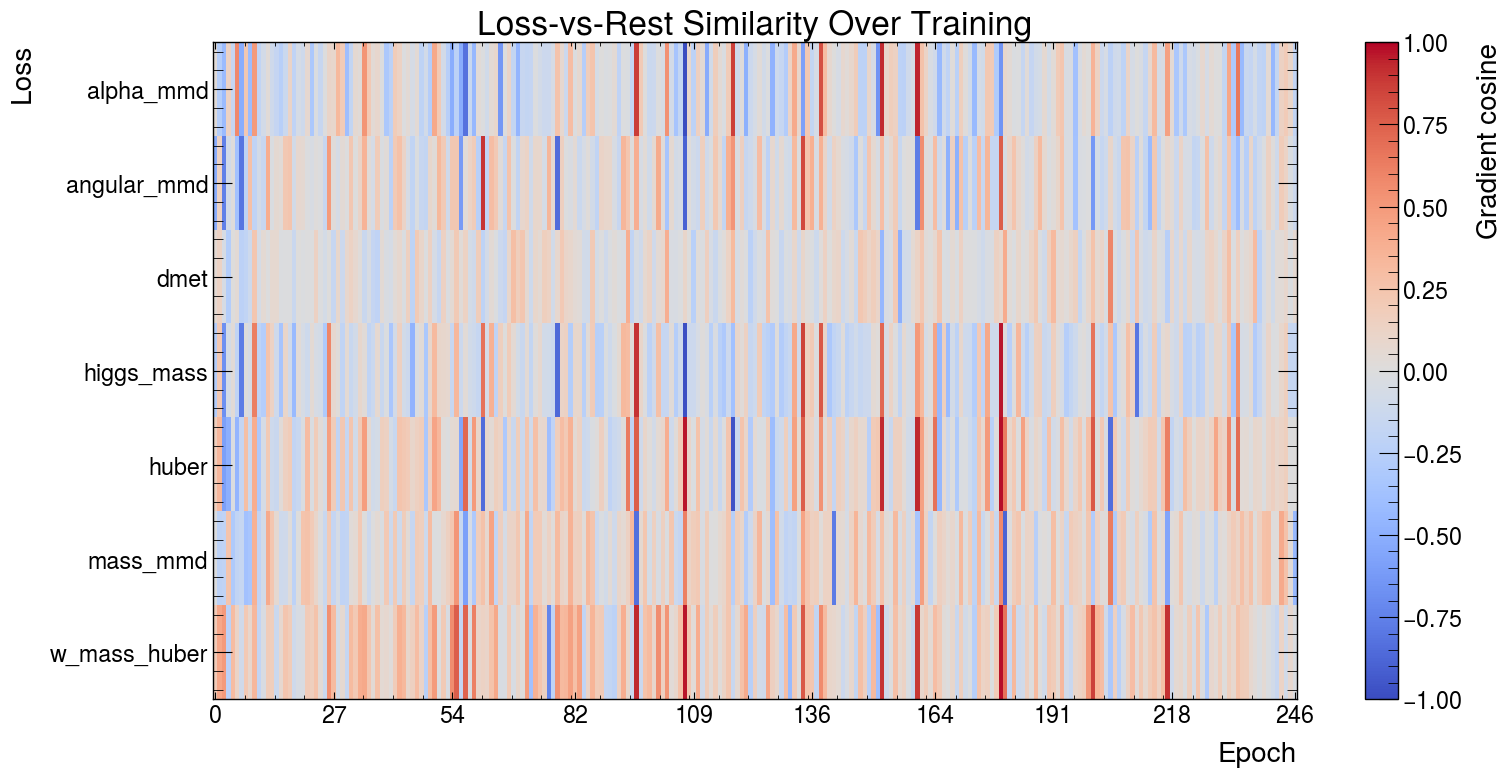

Visualized 0 pairwise, 7 total, and 7 rest grad_cos metrics across 247 logged rows.


In [35]:
metrics_path = LOG_DIR / "metrics.csv"
df = pd.read_csv(metrics_path)
grad_cols = sorted([col for col in df.columns if col.startswith("grad_cos/")])
if not grad_cols:
    print(f"No grad_cos columns found in {metrics_path}. Enable parameters.log_loss_gradient_cosines and rerun training.")
else:
    populated_counts = df[grad_cols].notna().sum()
    grad_cols = sorted(populated_counts[populated_counts > 0].index)
    if not grad_cols:
        print(f"Found {len(populated_counts)} grad_cos columns in {metrics_path}, but all values are empty.")
        print("No gradient-cosine values were emitted. Older training code required adaptive_loss_weights: true even when log_loss_gradient_cosines was enabled.")
        print("Rerun with the current independent gradient-cosine logging implementation.")
    else:
        total_grad_cols = [col for col in grad_cols if col.endswith("__total")]
        rest_grad_cols = [col for col in grad_cols if col.endswith("__rest")]
        pair_grad_cols = [col for col in grad_cols if col not in total_grad_cols and col not in rest_grad_cols]
        df_grad = df[df[grad_cols].notna().any(axis=1)].copy()
        x_col = "epoch" if "epoch" in df_grad.columns else "step"

        latest = df_grad[grad_cols].ffill().iloc[-1]

        if pair_grad_cols:
            heatmap = df_grad.set_index(x_col)[pair_grad_cols].ffill().T
            heatmap.index = [col.replace("grad_cos/", "").replace("__", " vs ") for col in heatmap.index]

            plt.figure(figsize=(16, max(8, 0.35 * len(pair_grad_cols))))
            plt.imshow(heatmap, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1, interpolation="nearest")
            plt.colorbar(label="Gradient cosine")
            plt.yticks(range(len(heatmap.index)), heatmap.index)
            tick_positions = np.linspace(0, len(heatmap.columns) - 1, min(10, len(heatmap.columns)), dtype=int)
            plt.xticks(tick_positions, heatmap.columns[tick_positions])
            plt.xlabel(x_col.capitalize())
            plt.ylabel("Loss pair")
            plt.title("Pairwise Similarity Over Training")
            plt.tight_layout()
            plt.show()

            pair_latest = latest[pair_grad_cols].dropna()
            loss_names = sorted({name for col in pair_grad_cols for name in col.replace("grad_cos/", "").split("__")})
            matrix = pd.DataFrame(np.nan, index=loss_names, columns=loss_names)
            for name in loss_names:
                matrix.loc[name, name] = 1.0
            for col, value in pair_latest.items():
                name_a, name_b = col.replace("grad_cos/", "").split("__")
                matrix.loc[name_a, name_b] = value
                matrix.loc[name_b, name_a] = value

            plt.figure(figsize=(10, 8))
            plt.imshow(matrix, cmap="coolwarm", vmin=-1, vmax=1)
            plt.colorbar(label="Gradient cosine")
            plt.xticks(range(len(loss_names)), loss_names, rotation=45, ha="right")
            plt.yticks(range(len(loss_names)), loss_names)
            plt.title(f"Pairwise Similarity Matrix ({x_col} {df_grad[x_col].iloc[-1]})")
            plt.tight_layout()
            plt.show()
        else:
            print("No populated pairwise grad_cos metrics found.")

        if total_grad_cols:
            total_heatmap = df_grad.set_index(x_col)[total_grad_cols].ffill().T
            total_heatmap.index = [
                col.replace("grad_cos/", "").replace("__total", "")
                for col in total_heatmap.index
            ]
            total_heatmap = total_heatmap.dropna(how="all")

            if total_heatmap.empty:
                print("No populated loss-vs-total grad_cos metrics found.")
            else:
                plt.figure(figsize=(16, max(8, 0.35 * len(total_heatmap))))
                plt.imshow(total_heatmap, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1, interpolation="nearest")
                plt.colorbar(label="Gradient cosine")
                plt.yticks(range(len(total_heatmap.index)), total_heatmap.index)
                tick_positions = np.linspace(0, len(total_heatmap.columns) - 1, min(10, len(total_heatmap.columns)), dtype=int)
                plt.xticks(tick_positions, total_heatmap.columns[tick_positions])
                plt.xlabel(x_col.capitalize())
                plt.ylabel("Loss")
                plt.title("Loss-vs-Total Similarity Over Training")
                plt.tight_layout()
                plt.show()
        else:
            print("No populated loss-vs-total grad_cos metrics found.")

        if rest_grad_cols:
            rest_heatmap = df_grad.set_index(x_col)[rest_grad_cols].ffill().T
            rest_heatmap.index = [
                col.replace("grad_cos/", "").replace("__rest", "")
                for col in rest_heatmap.index
            ]
            rest_heatmap = rest_heatmap.dropna(how="all")

            if rest_heatmap.empty:
                print("No populated loss-vs-rest grad_cos metrics found.")
            else:
                plt.figure(figsize=(16, max(8, 0.35 * len(rest_heatmap))))
                plt.imshow(rest_heatmap, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1, interpolation="nearest")
                plt.colorbar(label="Gradient cosine")
                plt.yticks(range(len(rest_heatmap.index)), rest_heatmap.index)
                tick_positions = np.linspace(0, len(rest_heatmap.columns) - 1, min(10, len(rest_heatmap.columns)), dtype=int)
                plt.xticks(tick_positions, rest_heatmap.columns[tick_positions])
                plt.xlabel(x_col.capitalize())
                plt.ylabel("Loss")
                plt.title("Loss-vs-Rest Similarity Over Training")
                plt.tight_layout()
                plt.show()
        else:
            print("No populated loss-vs-rest grad_cos metrics found.")

        print(f"Visualized {len(pair_grad_cols)} pairwise, {len(total_grad_cols)} total, and {len(rest_grad_cols)} rest grad_cos metrics across {len(df_grad)} logged rows.")


In [36]:
# import shap
# import numpy as np
# import matplotlib as mpl
# from matplotlib import pyplot as plt

# mpl.rcParams.update(mpl.rcParamsDefault)

# # Feature order follows load_data.py train_obj construction.
# feature_names = [
#     "lep+ px", "lep+ py", "lep+ pz", "lep+ energy",
#     "lep- px", "lep- py", "lep- pz", "lep- energy",
#     "jet1 px", "jet1 py", "jet1 pz", "jet1 energy",
#     "jet2 px", "jet2 py", "jet2 pz", "jet2 energy",
#     "MET px", "MET py",
#     "m_ll", "delta eta ll", "delta phi ll", "delta phi ll-MET"
# ]

# output_names = [
#     "W+ px", "W+ py", "W+ pz", "W+ energy [GeV]",
#     "W- px", "W- py", "W- pz", "W- energy [GeV]",
# ]

# background_sample = torch.tensor(train_features[0:256]).float().to(device)
# samples_to_explain = torch.tensor(train_features[512:512+1024]).float().to(device)
# x_explain = samples_to_explain.detach().cpu().numpy()

# if len(feature_names) != x_explain.shape[1]:
#     raise ValueError(f"Expected {len(feature_names)} features, got {x_explain.shape[1]}")

# explainer = shap.GradientExplainer(model, background_sample)
# shap_values = explainer.shap_values(samples_to_explain, nsamples=200)

# if isinstance(shap_values, list):
#     shap_values = np.stack(shap_values, axis=-1)

# importance_by_output = np.abs(shap_values).mean(axis=0)
# overall_importance = importance_by_output.mean(axis=1)
# top_overall = np.argsort(overall_importance)[::-1][:20]

# plt.figure(figsize=(9, 7))
# plt.barh(
#     [feature_names[idx] for idx in top_overall[::-1]],
#     overall_importance[top_overall[::-1]],
# )
# plt.xlabel("Mean |SHAP value| across outputs")
# plt.title("Overall SHAP Feature Importance", fontsize=15)
# plt.tight_layout()
# plt.show()

# heatmap_features = top_overall[::-1]
# plt.figure(figsize=(10, 8))
# plt.imshow(importance_by_output[heatmap_features], aspect="auto", cmap="viridis")
# plt.colorbar(label="Mean |SHAP value|")
# plt.yticks(range(len(heatmap_features)), [feature_names[idx] for idx in heatmap_features])
# plt.xticks(
#     range(min(len(output_names), importance_by_output.shape[1])),
#     output_names[:importance_by_output.shape[1]],
#     rotation=45,
#     ha="right",
# )
# plt.title("SHAP Importance by Feature and Output", fontsize=15)
# plt.tight_layout()
# plt.show()

# for i in range(shap_values.shape[-1]):
#     values = shap_values[:, :, i]
#     importance = importance_by_output[:, i]
#     top = np.argsort(importance)[::-1][:15]
#     output_label = output_names[i] if i < len(output_names) else f"output {i}"

#     print(f"Top features for {output_label}:")
#     for rank, idx in enumerate(top, start=1):
#         print(f"  {rank:2d}. {feature_names[idx]}: {importance[idx]:.6f}")

#     shap.summary_plot(
#         values,
#         x_explain,
#         feature_names=feature_names,
#         plot_type="bar",
#         max_display=15,
#         show=False,
#     )
#     plt.title(f"SHAP Feature Importance: {output_label}", fontsize=15)
#     plt.tight_layout()
#     plt.show()

#     shap.summary_plot(
#         values,
#         x_explain,
#         feature_names=feature_names,
#         plot_type="dot",
#         max_display=15,
#         show=False,
#     )
#     plt.title(f"SHAP Beeswarm: {output_label}", fontsize=15)
#     plt.tight_layout()
#     plt.show()

In [37]:
from scipy.stats import ks_2samp


def _alpha(x_batch, w4):
    w = w4[..., :8].reshape(-1, 2, 4)
    nu0 = w[:, 0] - x_batch[..., :4]
    nu1 = w[:, 1] - x_batch[..., 4:8]
    p0 = np.linalg.norm(nu0[..., :3], axis=-1)
    p1 = np.linalg.norm(nu1[..., :3], axis=-1)
    tot = p0 + p1
    frac = np.where(tot == 0, 0.5, p0 / np.where(tot == 0, 1.0, tot))
    return 2.0 * frac - 1.0


def _w_masses(w4):
    w = w4[..., :8].reshape(-1, 2, 4).reshape(-1, 4)
    m2 = w[..., 3] ** 2 - w[..., 0] ** 2 - w[..., 1] ** 2 - w[..., 2] ** 2
    return np.sqrt(np.clip(m2, 1e-6, None))


def _higgs_mass(w4):
    s = w4[..., :8].reshape(-1, 2, 4).sum(1)
    m2 = s[..., 3] ** 2 - s[..., 0] ** 2 - s[..., 1] ** 2 - s[..., 2] ** 2
    return np.sqrt(np.clip(m2, 1e-6, None))


alpha_ks = ks_2samp(_alpha(train_features, predictions),
                    _alpha(train_features, true_labels)).statistic
mw_ks = ks_2samp(_w_masses(predictions), _w_masses(true_labels)).statistic

pred_mh = _higgs_mass(predictions)
true_mh = _higgs_mass(true_labels)
within2 = 100.0 * np.mean(np.abs(pred_mh - 125.0) < 2.0)
within5 = 100.0 * np.mean(np.abs(pred_mh - 125.0) < 5.0)

print("Distribution-faithfulness and delta-like-mH summary:")
print(f"  events          : {len(true_labels)}")
print(f"  alpha KS        : {alpha_ks:.4f}   (lower = more faithful)")
print(f"  W-mass KS       : {mw_ks:.4f}   (lower = more faithful)")
print(f"  predicted mH    : mean {pred_mh.mean():.2f} GeV, std {pred_mh.std():.2f} GeV")
print(f"  mH within 2 GeV : {within2:.1f}%")
print(f"  mH within 5 GeV : {within5:.1f}%")
print(f"  |pred - truth|  : {np.abs(pred_mh - true_mh).mean():.2f} GeV")

Distribution-faithfulness and delta-like-mH summary:
  events          : 185968
  alpha KS        : 0.0424   (lower = more faithful)
  W-mass KS       : 0.0221   (lower = more faithful)
  predicted mH    : mean 125.18 GeV, std 2.55 GeV
  mH within 2 GeV : 91.4%
  mH within 5 GeV : 99.5%
  |pred - truth|  : 0.95 GeV
